In [14]:
import os
import logging
import sys
import inspect
from copy import copy


import itertools
import pandas as pd
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.distributions as dist
import torch.optim as optim
from torch.optim import Adam, RMSprop
import torch.utils.data
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import npyx.c4.dl_utils as m
import npyx.c4.dl_transforms as custom_transforms
import torchvision.transforms as transforms

from pathlib import Path
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import npyx

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Set seed and constants

In [15]:
home = str(Path.home())
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DIR = os.getcwd()
SEED = 1234
USE_CUDA = torch.cuda.is_available()
INIT_WEIGHTS = False

npyx.ml.set_seed(SEED)
torch.set_default_dtype(torch.float32)

Random seed 1234 has been set.


Import dataset and use only unlabelled data

# Data 

In [16]:
acg_3d = np.load(
    os.path.join(
        home,
        "Desktop",
        "C4_data_23_05_31/acgs_vs_firing_rate/unlabelled_acgs_3d_augmented_logscale.npy",
    )
)
acg_3d = acg_3d.reshape(-1, 10, 201)
# Multiply by 10 to normalise to 100 Hz as the max.
acg_3d = acg_3d * 10

# Normalise each one to be between 0 and 1
acg_3d_norm = np.nan_to_num(acg_3d / acg_3d.max(axis=(1, 2), keepdims=True))
DATASET_LEN = len(acg_3d_norm)
DATASET_LEN

18505

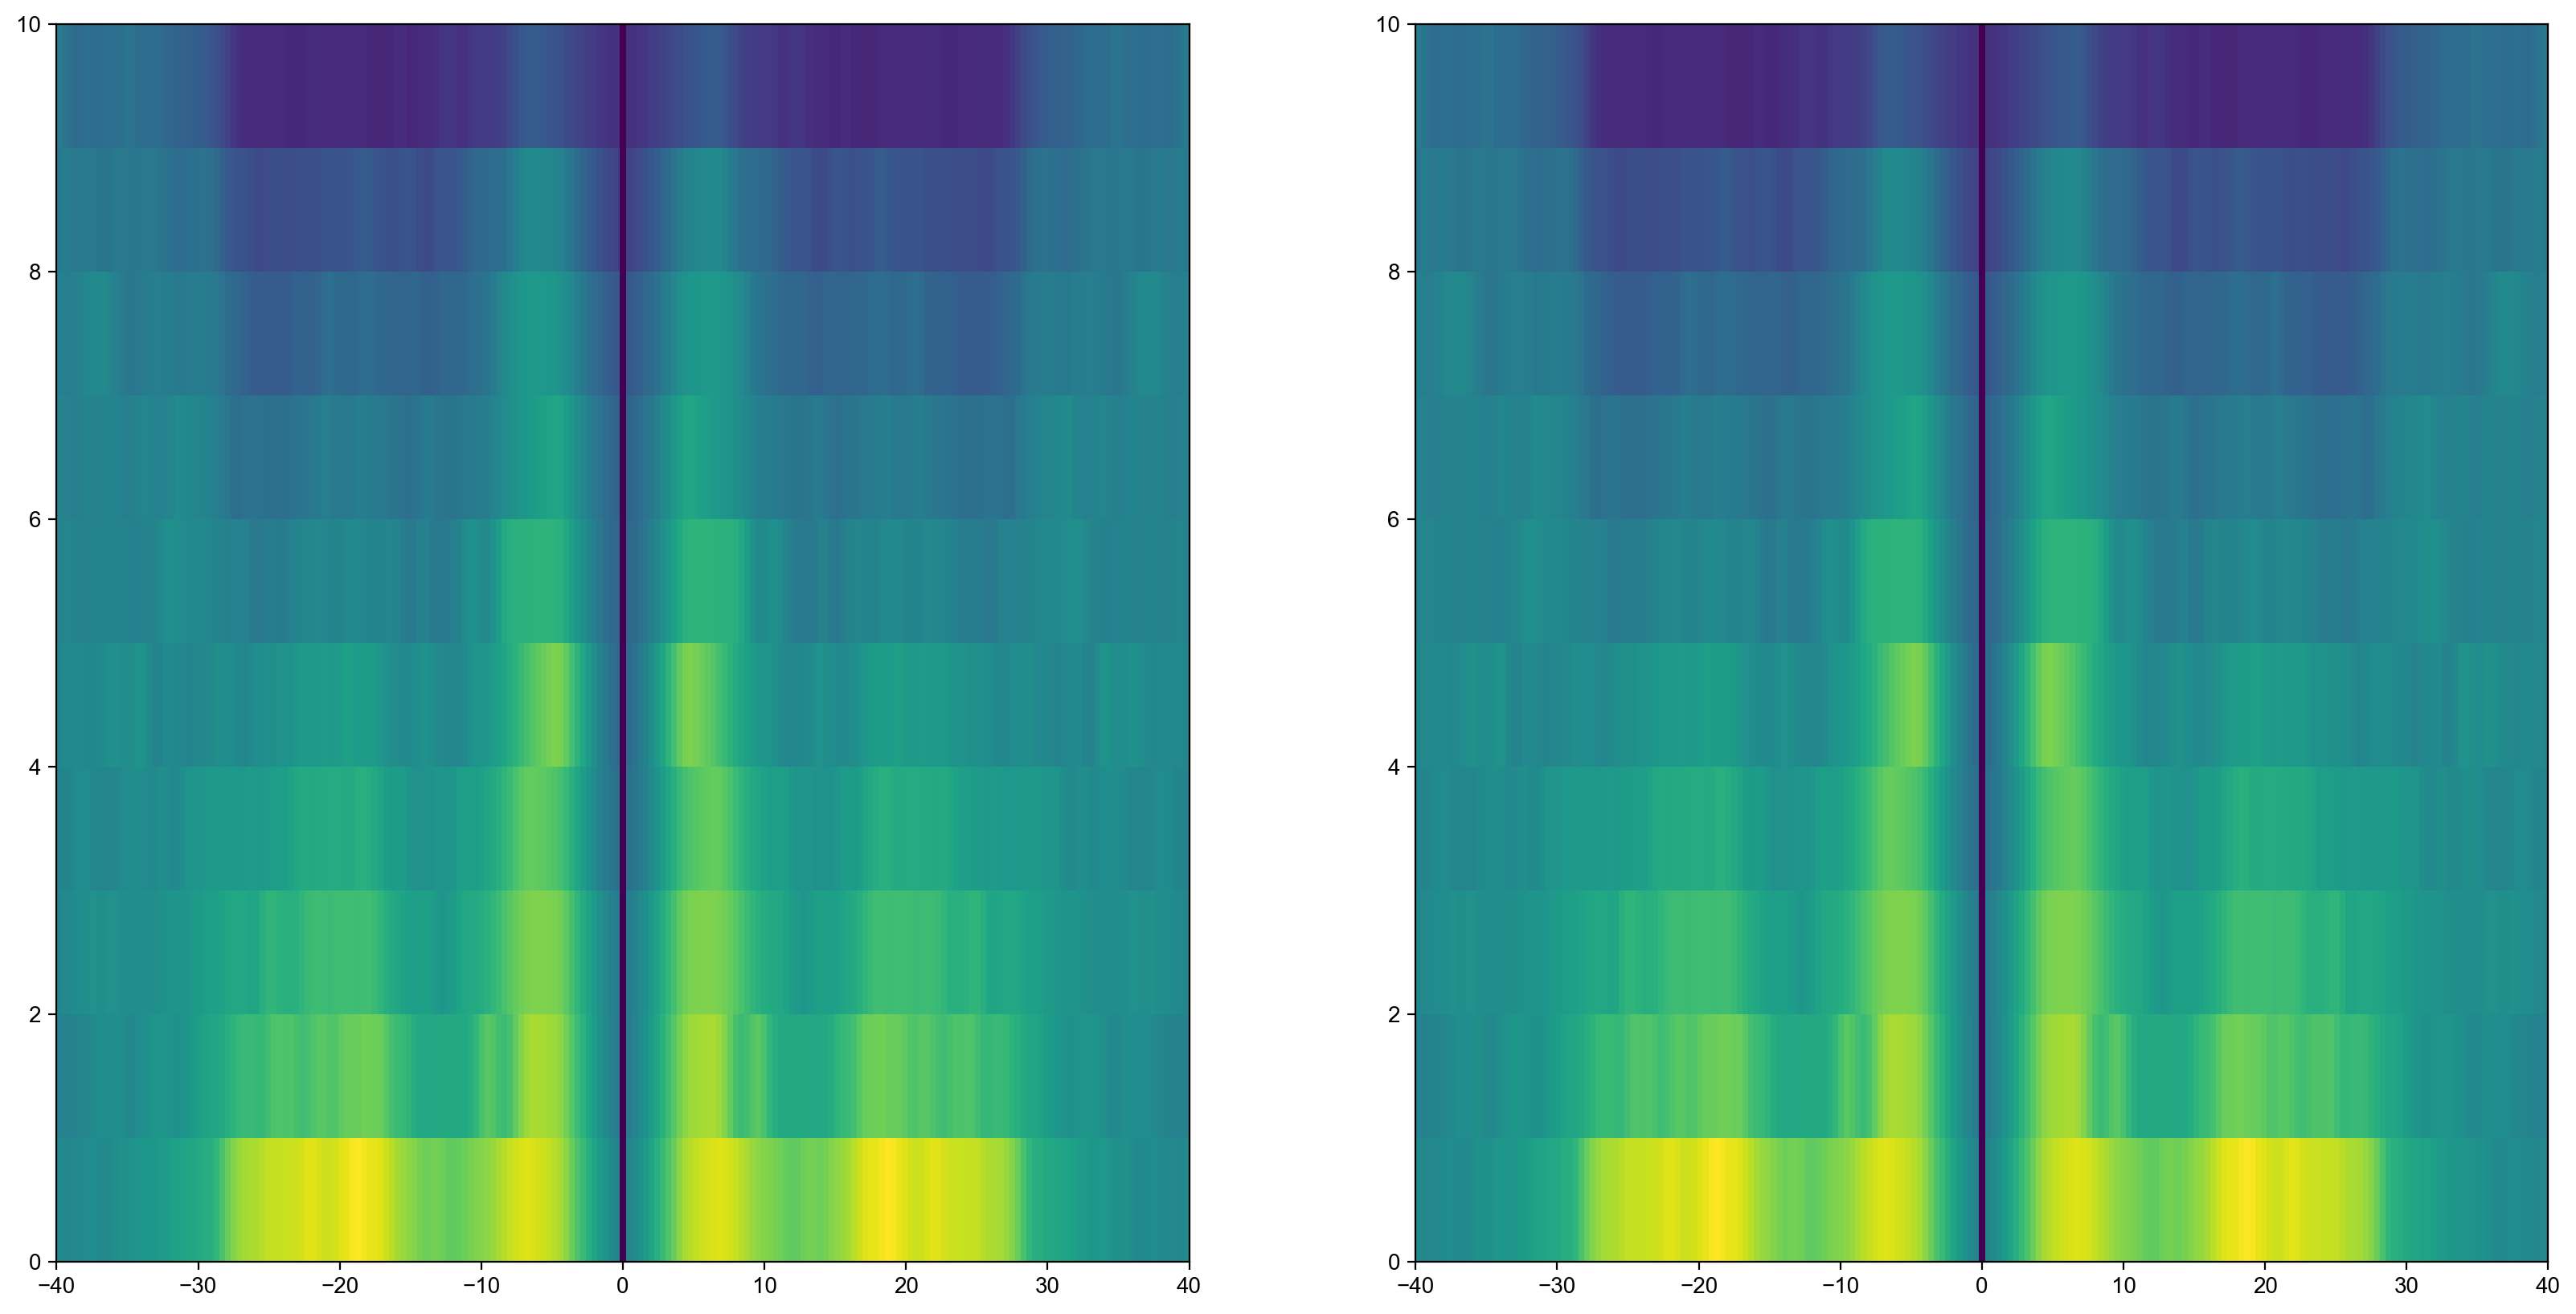

In [17]:
idx = 0
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(acg_3d[idx], aspect="auto", extent=[-40, 40, 0, 10])
ax[1].imshow(acg_3d_norm[idx], aspect="auto", extent=[-40, 40, 0, 10])

In [18]:
test = torch.nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=(1, 10)),
    nn.MaxPool2d(kernel_size=(2, 2)),
    nn.Conv2d(8, 16, (5, 1)),
    nn.MaxPool2d(kernel_size=(1, 2)),
)

In [19]:
test_tensor = torch.randn(1, 1, 10, 101)
test(test_tensor).shape

torch.Size([1, 16, 1, 23])

In [20]:
16 * 23

368

In [21]:
class ACG3Dataset(data.Dataset):
    """Dataset of waveforms as images. Every batch will have shape:
    (batch_size, 1, N_CHANNELS, CENTRAL_RANGE)"""

    def __init__(
        self,
        data: np.ndarray,
    ):
        """
        Args:
            data (ndarray): Array of data points, with wvf and acg concatenated
            labels (string): Array of labels for the provided data
            raw_spikes (ndarray): Array of raw spikes for the provided data
        """
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx, transform=None):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        return self.data[idx, :].astype("float32").reshape(1, -1)

# Models

In [22]:
class CustomMSELoss(nn.Module):
    def __init__(self, weight_factor=2.0):
        super(CustomMSELoss, self).__init__()
        self.weight_factor = weight_factor
        self.mse_loss = nn.MSELoss(reduction="none")

    def forward(self, input, target):
        # Compute the MSE loss for the entire image without reduction
        mse_loss = self.mse_loss(input, target)

        # Define the weight mask to assign higher weight to specific region
        weight_mask = torch.ones_like(target)
        weight_mask[:, :, :, :20] *= self.weight_factor

        return mse_loss * weight_mask

In [23]:
class Encoder(nn.Module):
    def __init__(self, d_latent, initialise=False):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=(1, 10))
        self.maxpool1 = nn.AvgPool2d(kernel_size=(2, 2))
        self.batchnorm1 = nn.BatchNorm2d(8)

        self.conv2 = nn.Conv2d(8, 16, (5, 1))
        self.maxpool2 = nn.AvgPool2d(kernel_size=(1, 2))
        self.batchnorm2 = nn.BatchNorm2d(16)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 1 * 23, 200)
        self.fc2 = nn.Linear(200, d_latent * 2)
        self.d_latent = d_latent
        self.dropout = nn.Dropout(0.2)

        if initialise:
            self.conv1.weight.data.normal_(0, 0.001)
            self.conv1.bias.data.normal_(0, 0.001)

            self.conv2.weight.data.normal_(0, 0.001)
            self.conv2.bias.data.normal_(0, 0.001)

            self.fc1.weight.data.normal_(0, 0.001)
            self.fc1.bias.data.normal_(0, 0.001)

            self.fc2.weight.data.normal_(0, 0.001)
            self.fc2.bias.data.normal_(0, 0.001)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(self.maxpool1(x))
        x = self.batchnorm1(x)
        x = self.conv2(x)
        x = F.relu(self.maxpool2(x))
        x = self.batchnorm2(x)
        x = self.flatten(x)
        h = self.dropout(F.relu(self.fc1(x)))
        h = self.fc2(h)
        # split the output into mu and log_var
        mu = h[:, : self.d_latent]
        log_var = h[:, self.d_latent :]
        # return mu and log_var
        return dist.Normal(mu, torch.exp(log_var))


class Decoder(nn.Module):
    def __init__(self, d_latent, initialise=False):
        super().__init__()
        self.d_latent = d_latent
        self.fc1 = nn.Linear(d_latent, 250)
        self.fc2 = nn.Linear(250, 500)
        self.fc3 = nn.Linear(500, (10 * 101))

        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.2)

        if initialise:
            self.fc1.weight.data.normal_(0, 0.001)
            self.fc1.bias.data.normal_(0, 0.001)

            self.fc2.weight.data.normal_(0, 0.001)
            self.fc2.bias.data.normal_(0, 0.001)

            self.fc3.weight.data.normal_(0, 0.001)
            self.fc3.bias.data.normal_(0, 0.001)

    def forward(self, z):
        # flatten the latent vector
        z = z.view(z.shape[0], -1)
        h = self.dropout1(F.relu(self.fc1(z)))
        h = self.dropout2(F.relu(self.fc2(h)))
        X_reconstructed = self.fc3(h)

        # X_reconstructed = torch.sigmoid(X_reconstructed)

        return X_reconstructed.reshape(-1, 1, 10, 101)


def ELBO_VAE(enc, dec, X, beta=1, n_samples=10):
    """

    INPUT:
    enc : Instance of `Encoder` class, which returns a distribution
          over Z when called on a batch of inputs X
    dec : Instance of `Decoder` class, which returns a distribution
          over X when called on a batch of inputs Z
    X   : A batch of datapoints, torch.FloatTensor of shape = (batch_size, 1, 10, 60).

    """

    batch_size = X.shape[0]
    ELBO = torch.zeros(batch_size).to(DEVICE)
    for _ in range(n_samples):
        q_z = enc.forward(X)  # q(Z | X)
        z = (
            q_z.rsample()
        )  # Samples from the encoder posterior q(Z | X) using the reparameterization trick

        reconstruction = dec.forward(z)  # distribution p(x | z)

        prior = dist.Normal(
            torch.zeros_like(q_z.loc).to(DEVICE), torch.ones_like(q_z.scale).to(DEVICE)
        )

        custom_mse = CustomMSELoss(weight_factor=1.5)

        MSE = custom_mse(reconstruction, X).sum(dim=(1, 2, 3))

        KLD = dist.kl_divergence(q_z, prior).sum(dim=1)

        ELBO += MSE + beta * (batch_size / DATASET_LEN) * KLD

    return (ELBO / n_samples).mean()

In [24]:
def generate_kl_weight(epochs, beta=1):
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))

    weight = np.logspace(5, -20, epochs)
    weight = sigmoid(-np.log10(weight)) * beta

    return weight

# Choose parameters and train

In [25]:
D_LATENT = 10
BETA = 5
BATCH_SIZE = 32

In [26]:
input_data = acg_3d[:, :, 100:]

In [27]:
dataset = ACG3Dataset(input_data)
train_loader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [28]:
npyx.ml.set_seed(SEED)
torch.cuda.empty_cache()
initialise = False
enc, dec = Encoder(D_LATENT, initialise), Decoder(D_LATENT, initialise)
enc.to(DEVICE)
dec.to(DEVICE)
enc.train()
dec.train()

lr = 5e-4

optim_args = {
    "params": itertools.chain(enc.parameters(), dec.parameters()),
    "lr": lr,
}
opt_vae = optim.Adam(**optim_args)

# Add a scheduler
# scheduler = optim.lr_scheduler.MultiStepLR(
#     opt_vae, milestones=[90, 120, 140], gamma=0.5
# )

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt_vae, 20, 1, last_epoch=-1
)

N_epochs = 60
losses = []

kl_weights = generate_kl_weight(N_epochs, beta=BETA)


for epoch in tqdm(range(N_epochs), desc="Epochs"):
    train_loss = 0.0
    for X in train_loader:
        X = X.to(DEVICE)
        X = X.reshape(-1, 1, 10, 101)
        opt_vae.zero_grad()
        loss = ELBO_VAE(enc, dec, X, beta=kl_weights[epoch])
        loss.backward()
        opt_vae.step()
        train_loss += loss.item() * X.shape[0] / len(dataset)
    scheduler.step()
    losses.append(train_loss)

Random seed 1234 has been set.


Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

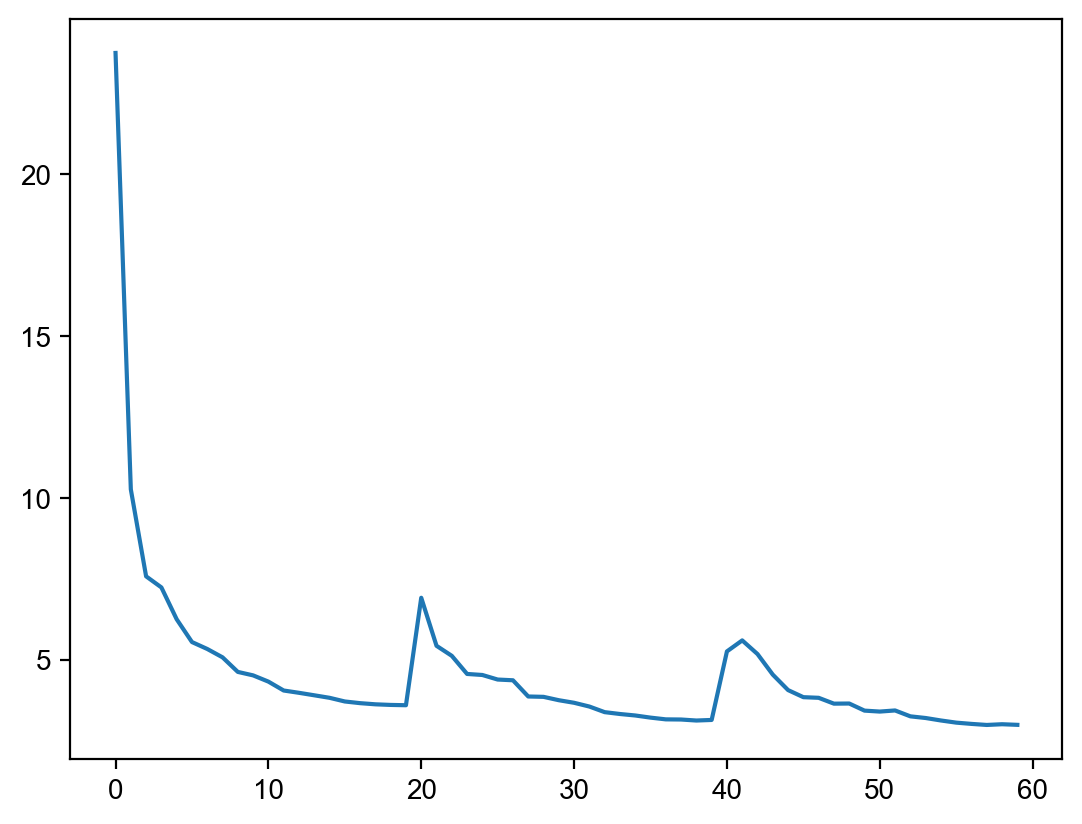

In [29]:
plt.plot(losses)

In [30]:
def reflected(img):
    if img.ndim == 1:
        return np.concatenate((img[::-1], img))
    return np.concatenate((img[:, ::-1], img), axis=1)

In [31]:
def plot_random_reconstruction(dataset, enc, dec, n_neurons=1):
    """
    Plots a random neuron from the dataset. Optionally, can specify a label
    """

    if n_neurons > dataset.shape[0]:
        print(f"Only {dataset.shape[0]} neurons to plot")
        n_neurons = dataset.shape[0]

    idx = np.random.choice(range(dataset.shape[0]), n_neurons, replace=False)
    for i in idx:
        fig, axs = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True)
        acg_original = dataset[i]
        axs[0, 0].imshow(
            reflected(acg_original), aspect="auto", extent=[-40, 40, 0, 10]
        )
        axs[0, 0].set_title("Original 3D ACG")

        axs[0, 1].plot(reflected(acg_original[-1, :]), lw=4, c="red", alpha=1)
        axs[0, 1].set_title("Original 1D ACG")

        with torch.no_grad():
            network_input = torch.tensor(acg_original.reshape(1, 1, 10, 101)).float()
            acg_reconstructed = (
                dec(enc(network_input).mean).reshape(10, 101).detach().numpy()
            )

        axs[1, 0].imshow(
            reflected(acg_reconstructed), aspect="auto", extent=[-40, 40, 0, 10]
        )
        axs[1, 0].set_title("Reconstructed 3D ACG")

        axs[1, 1].plot(reflected(acg_reconstructed[-1, :]), lw=4, c="red", alpha=1)
        axs[1, 1].set_title("Reconstructed 1D ACG")

        plt.show()

In [32]:
enc.cpu().eval()
dec.cpu().eval()

Decoder(
  (fc1): Linear(in_features=10, out_features=250, bias=True)
  (fc2): Linear(in_features=250, out_features=500, bias=True)
  (fc3): Linear(in_features=500, out_features=1010, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (dropout2): Dropout(p=0.2, inplace=False)
)

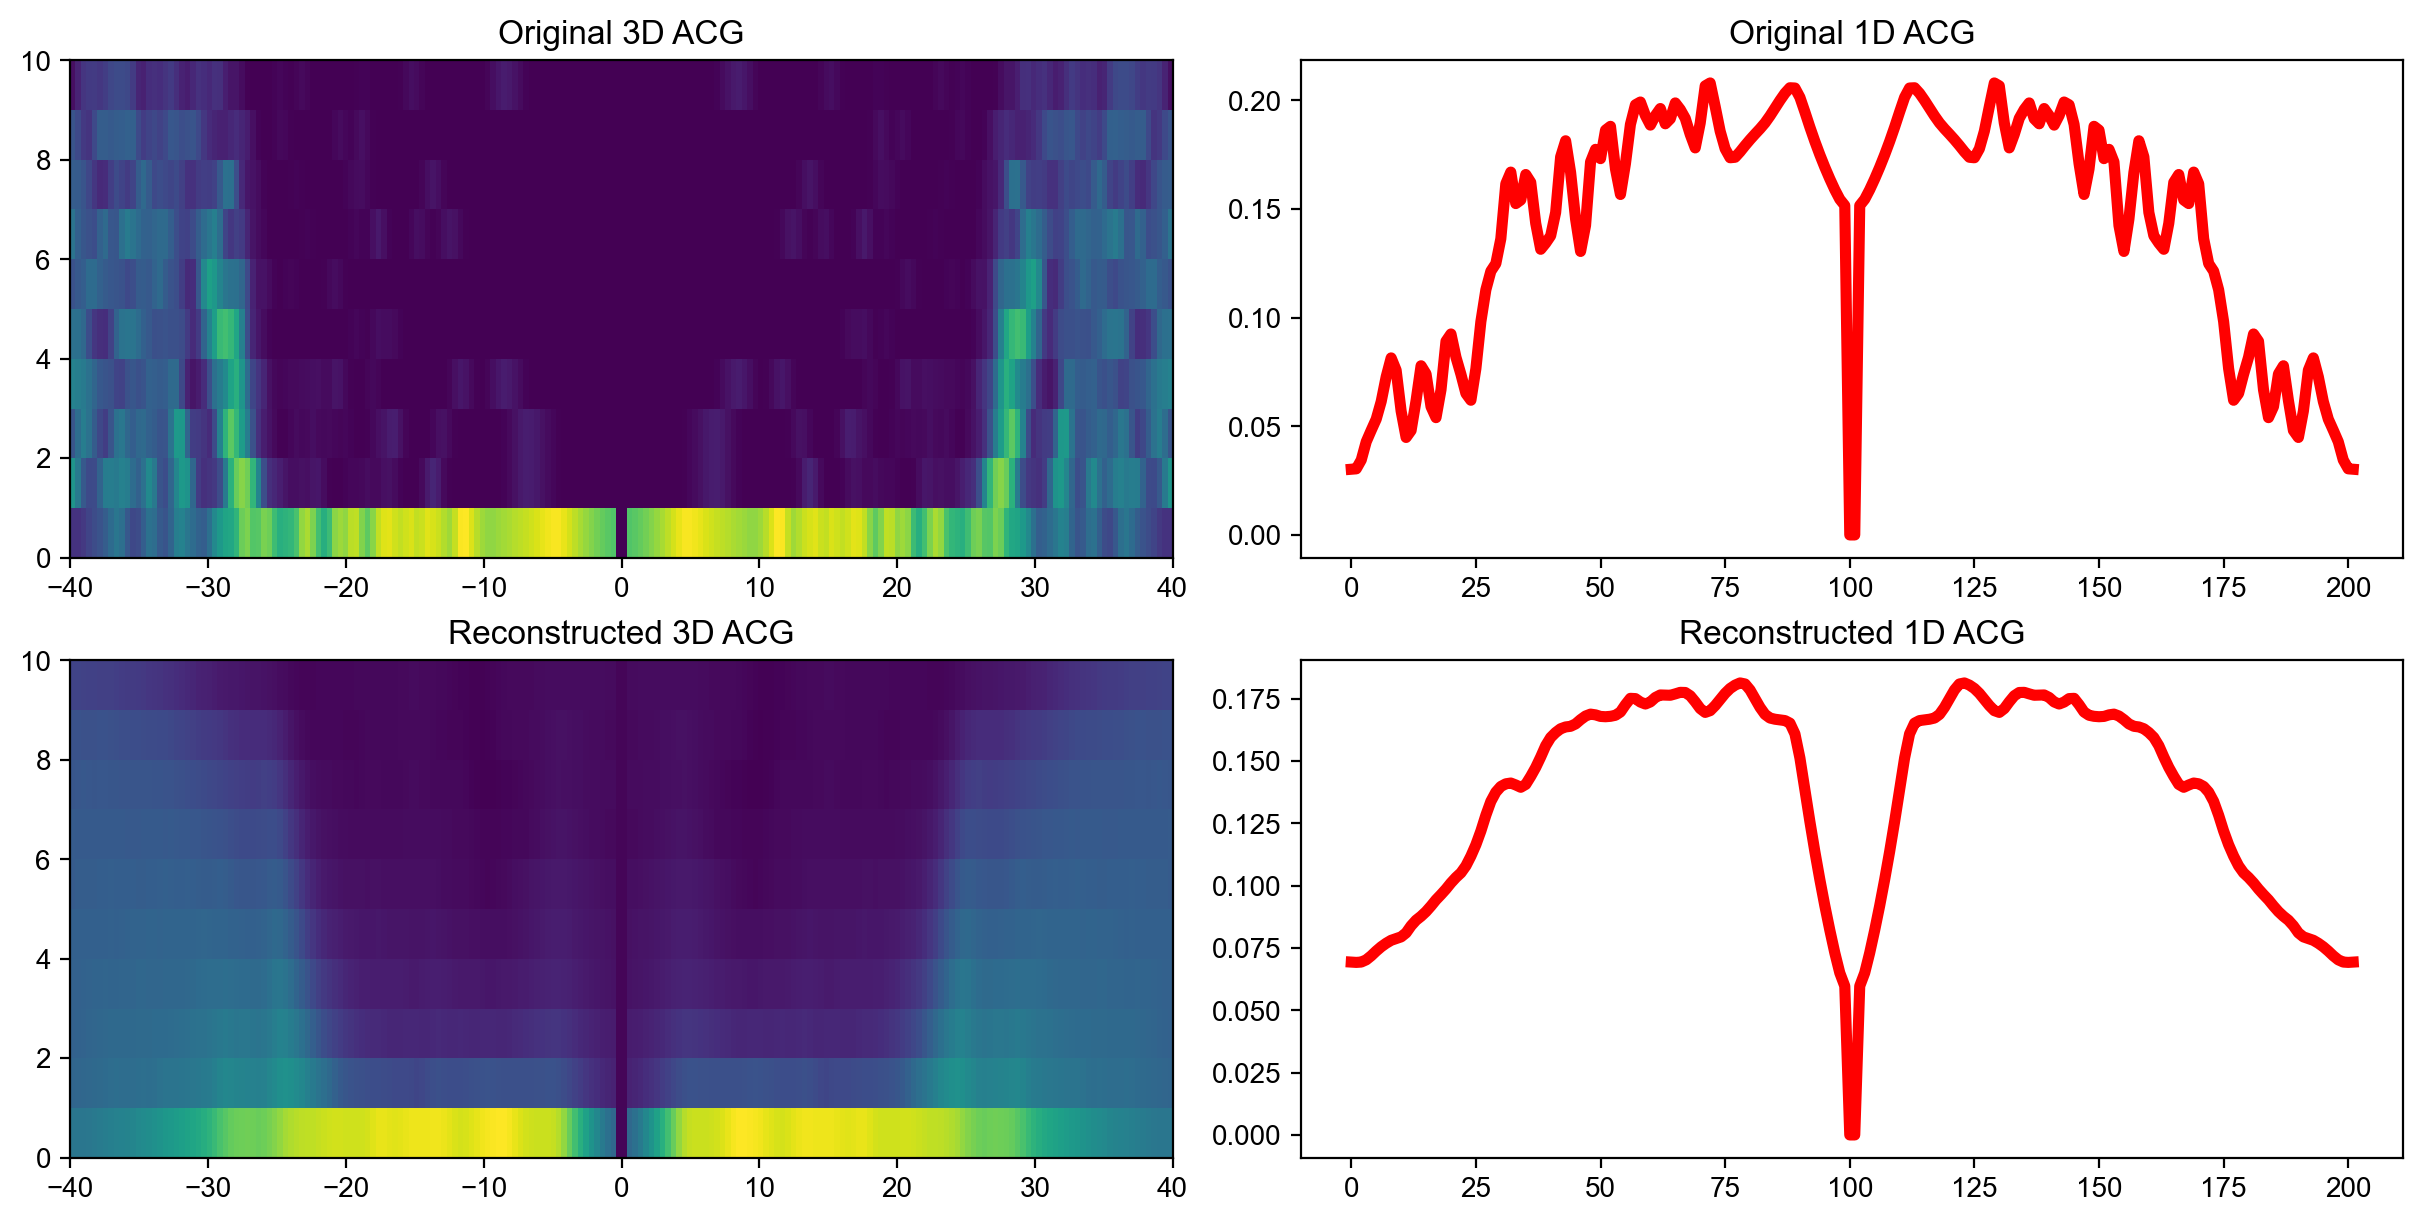

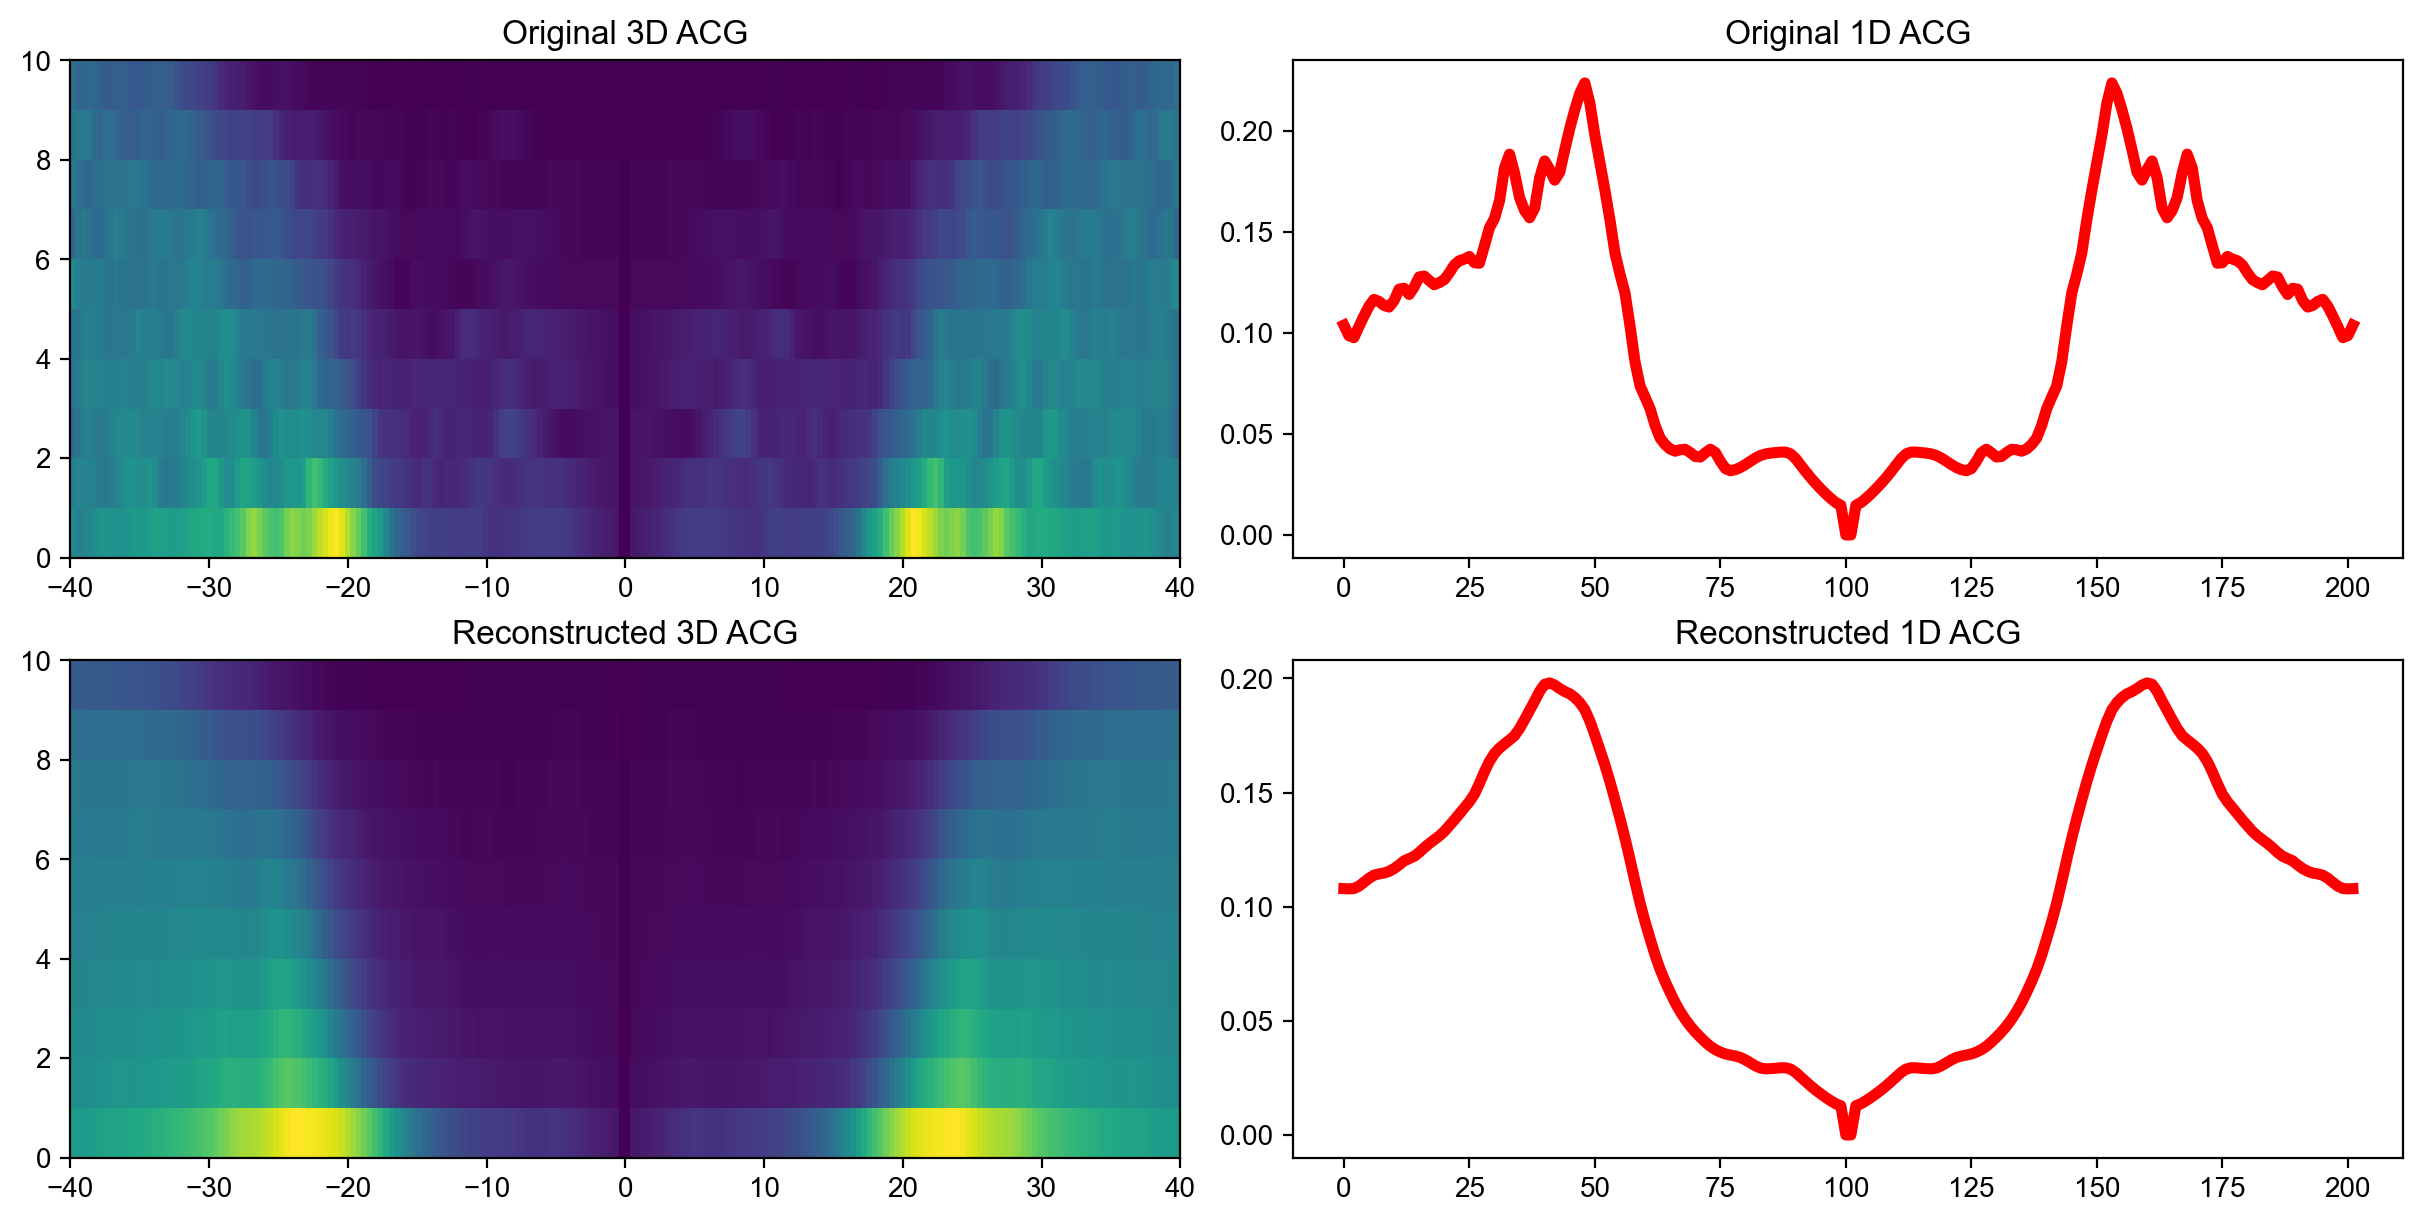

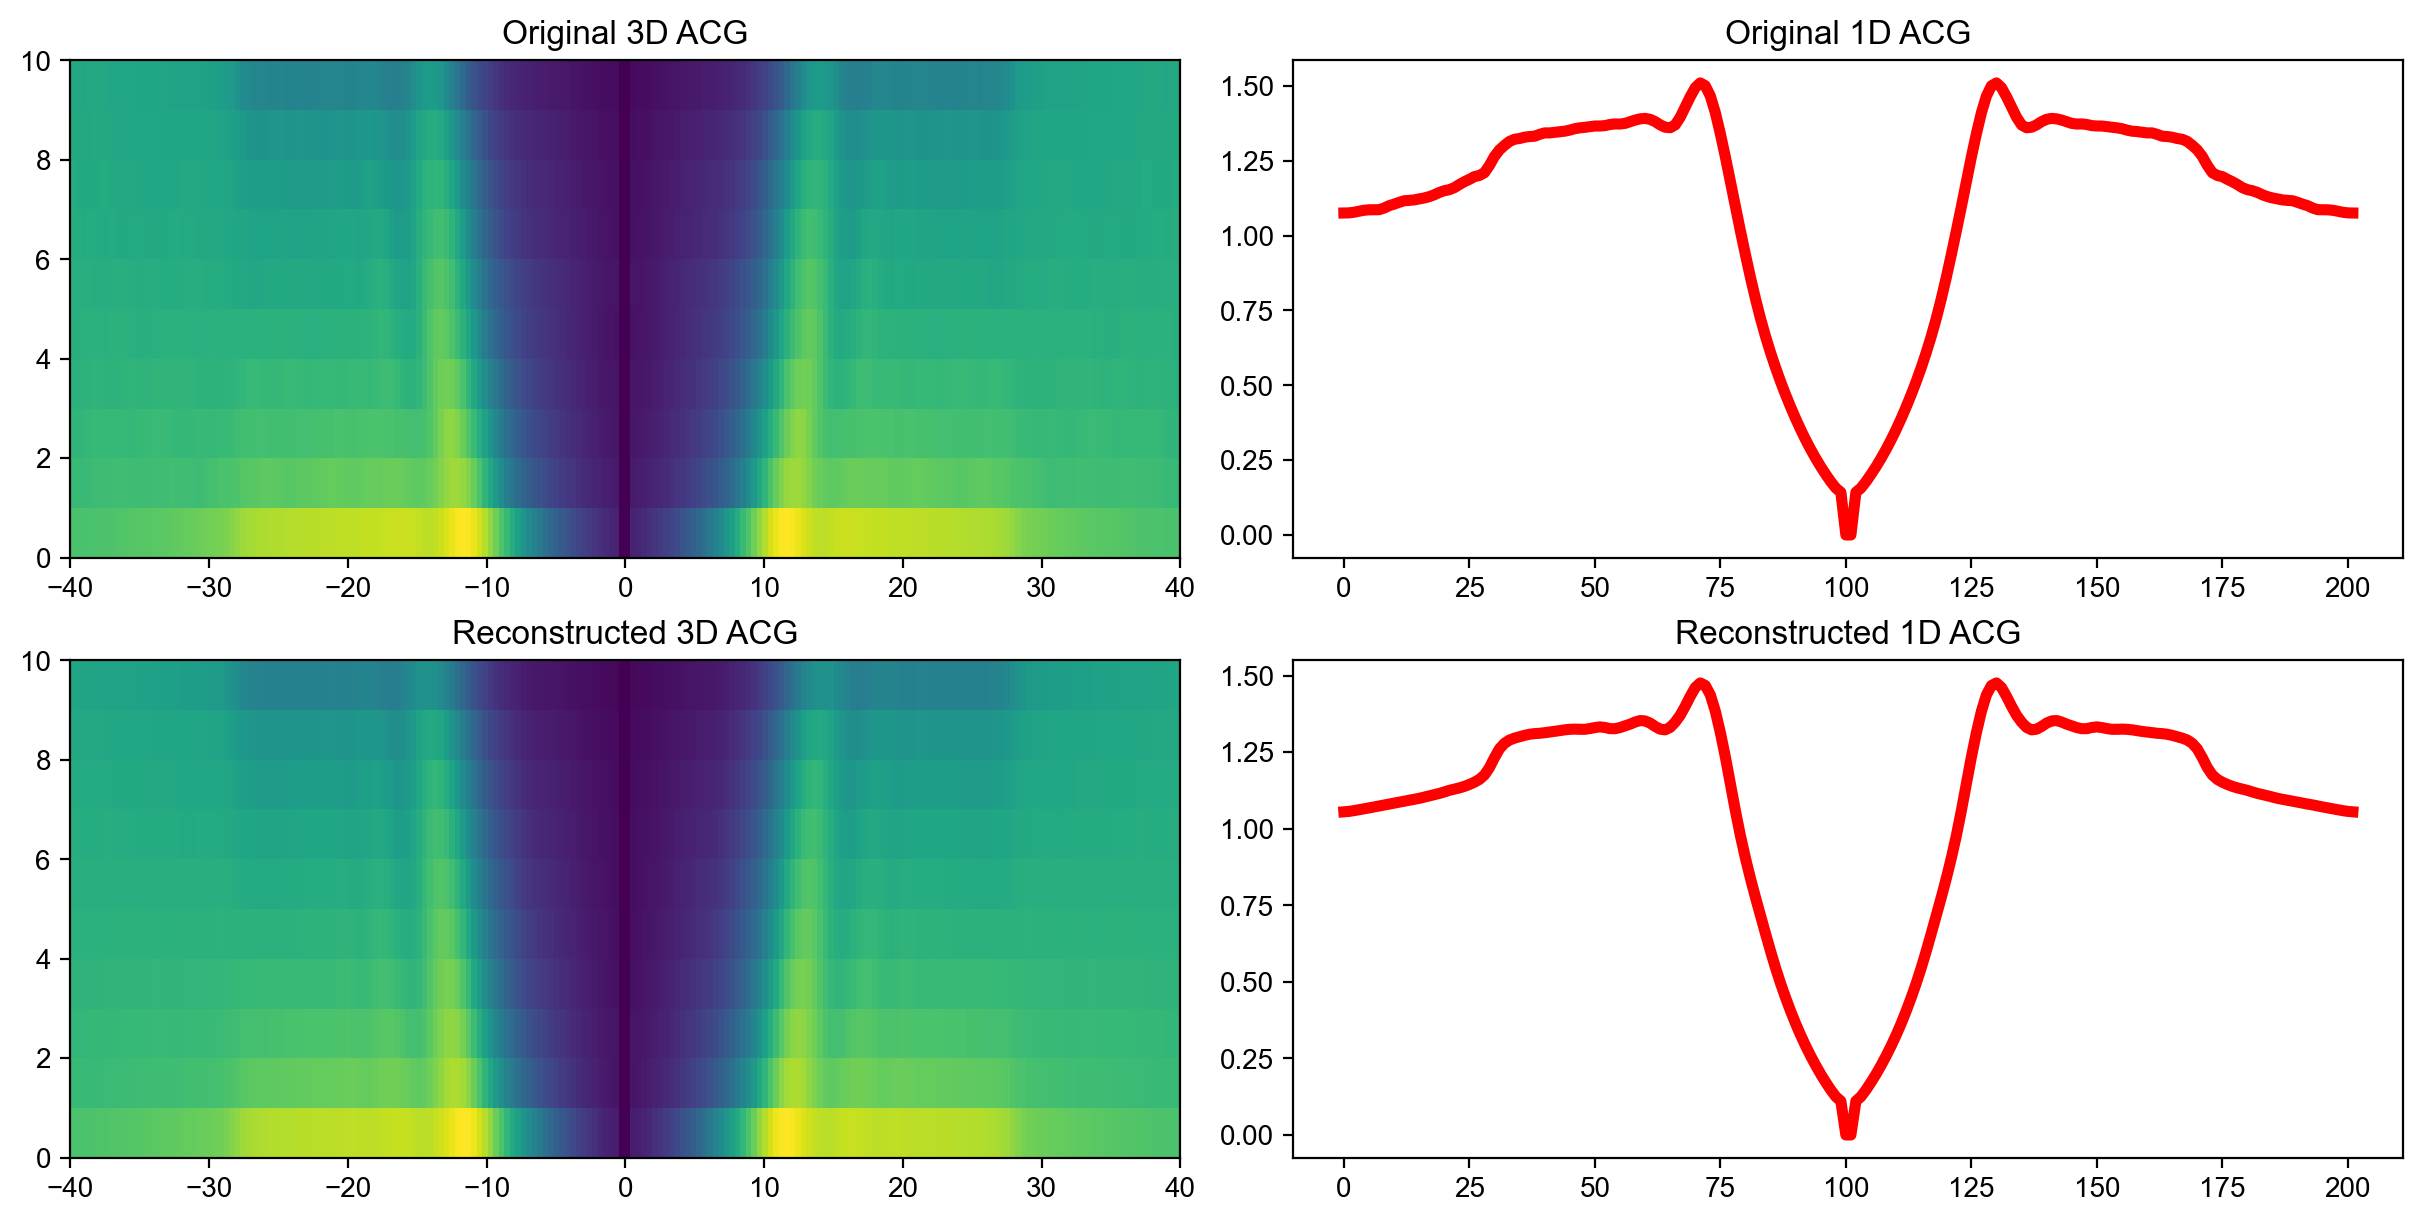

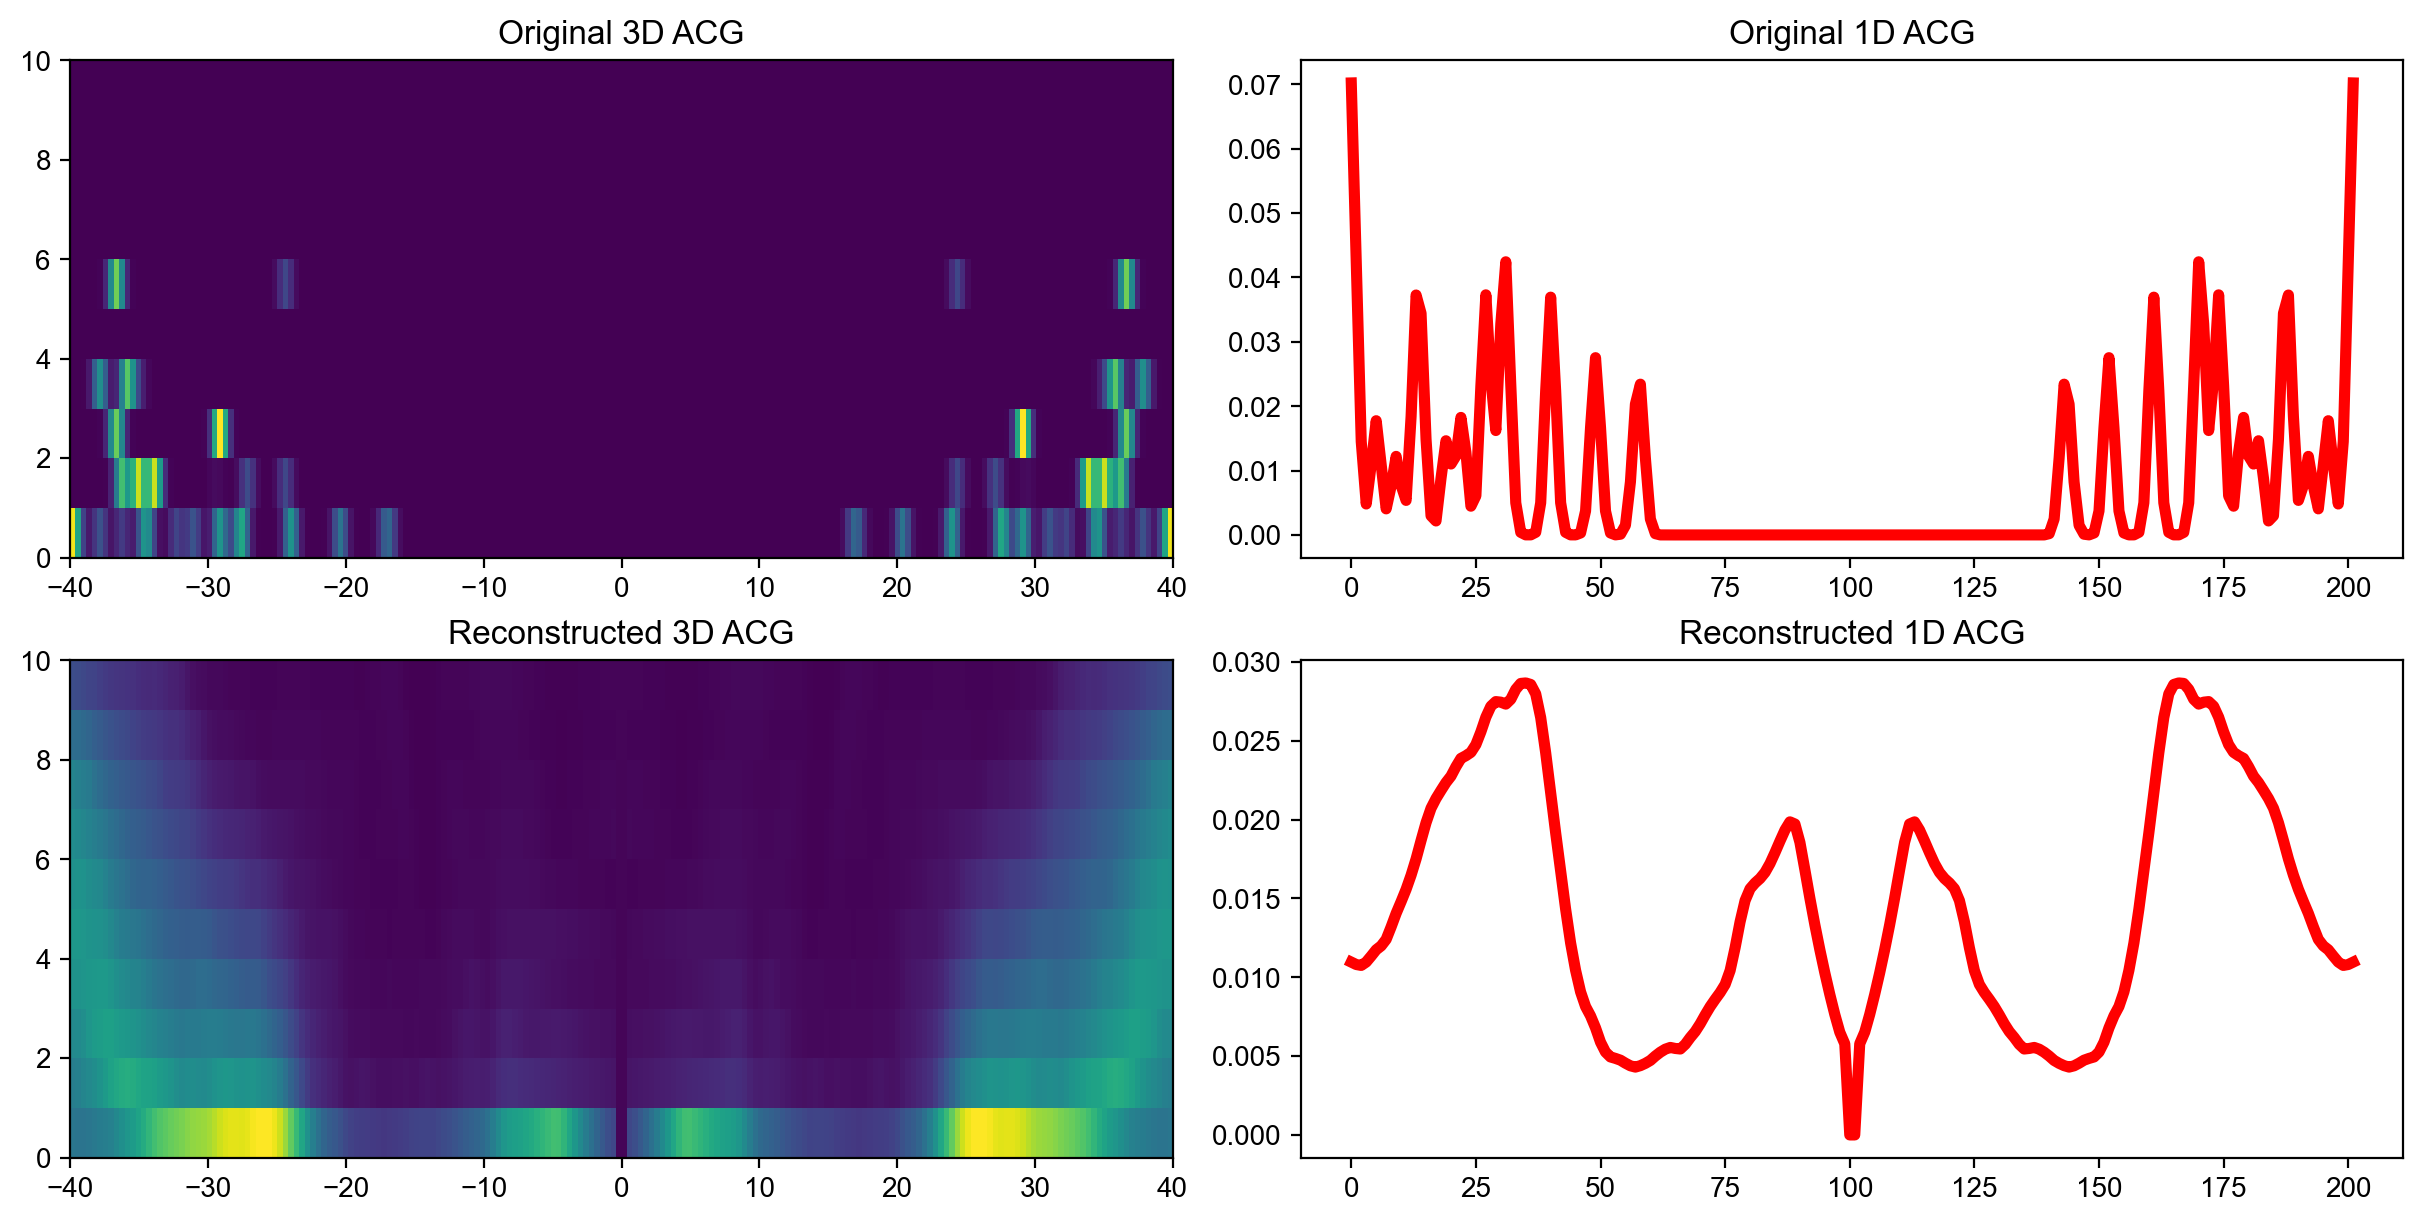

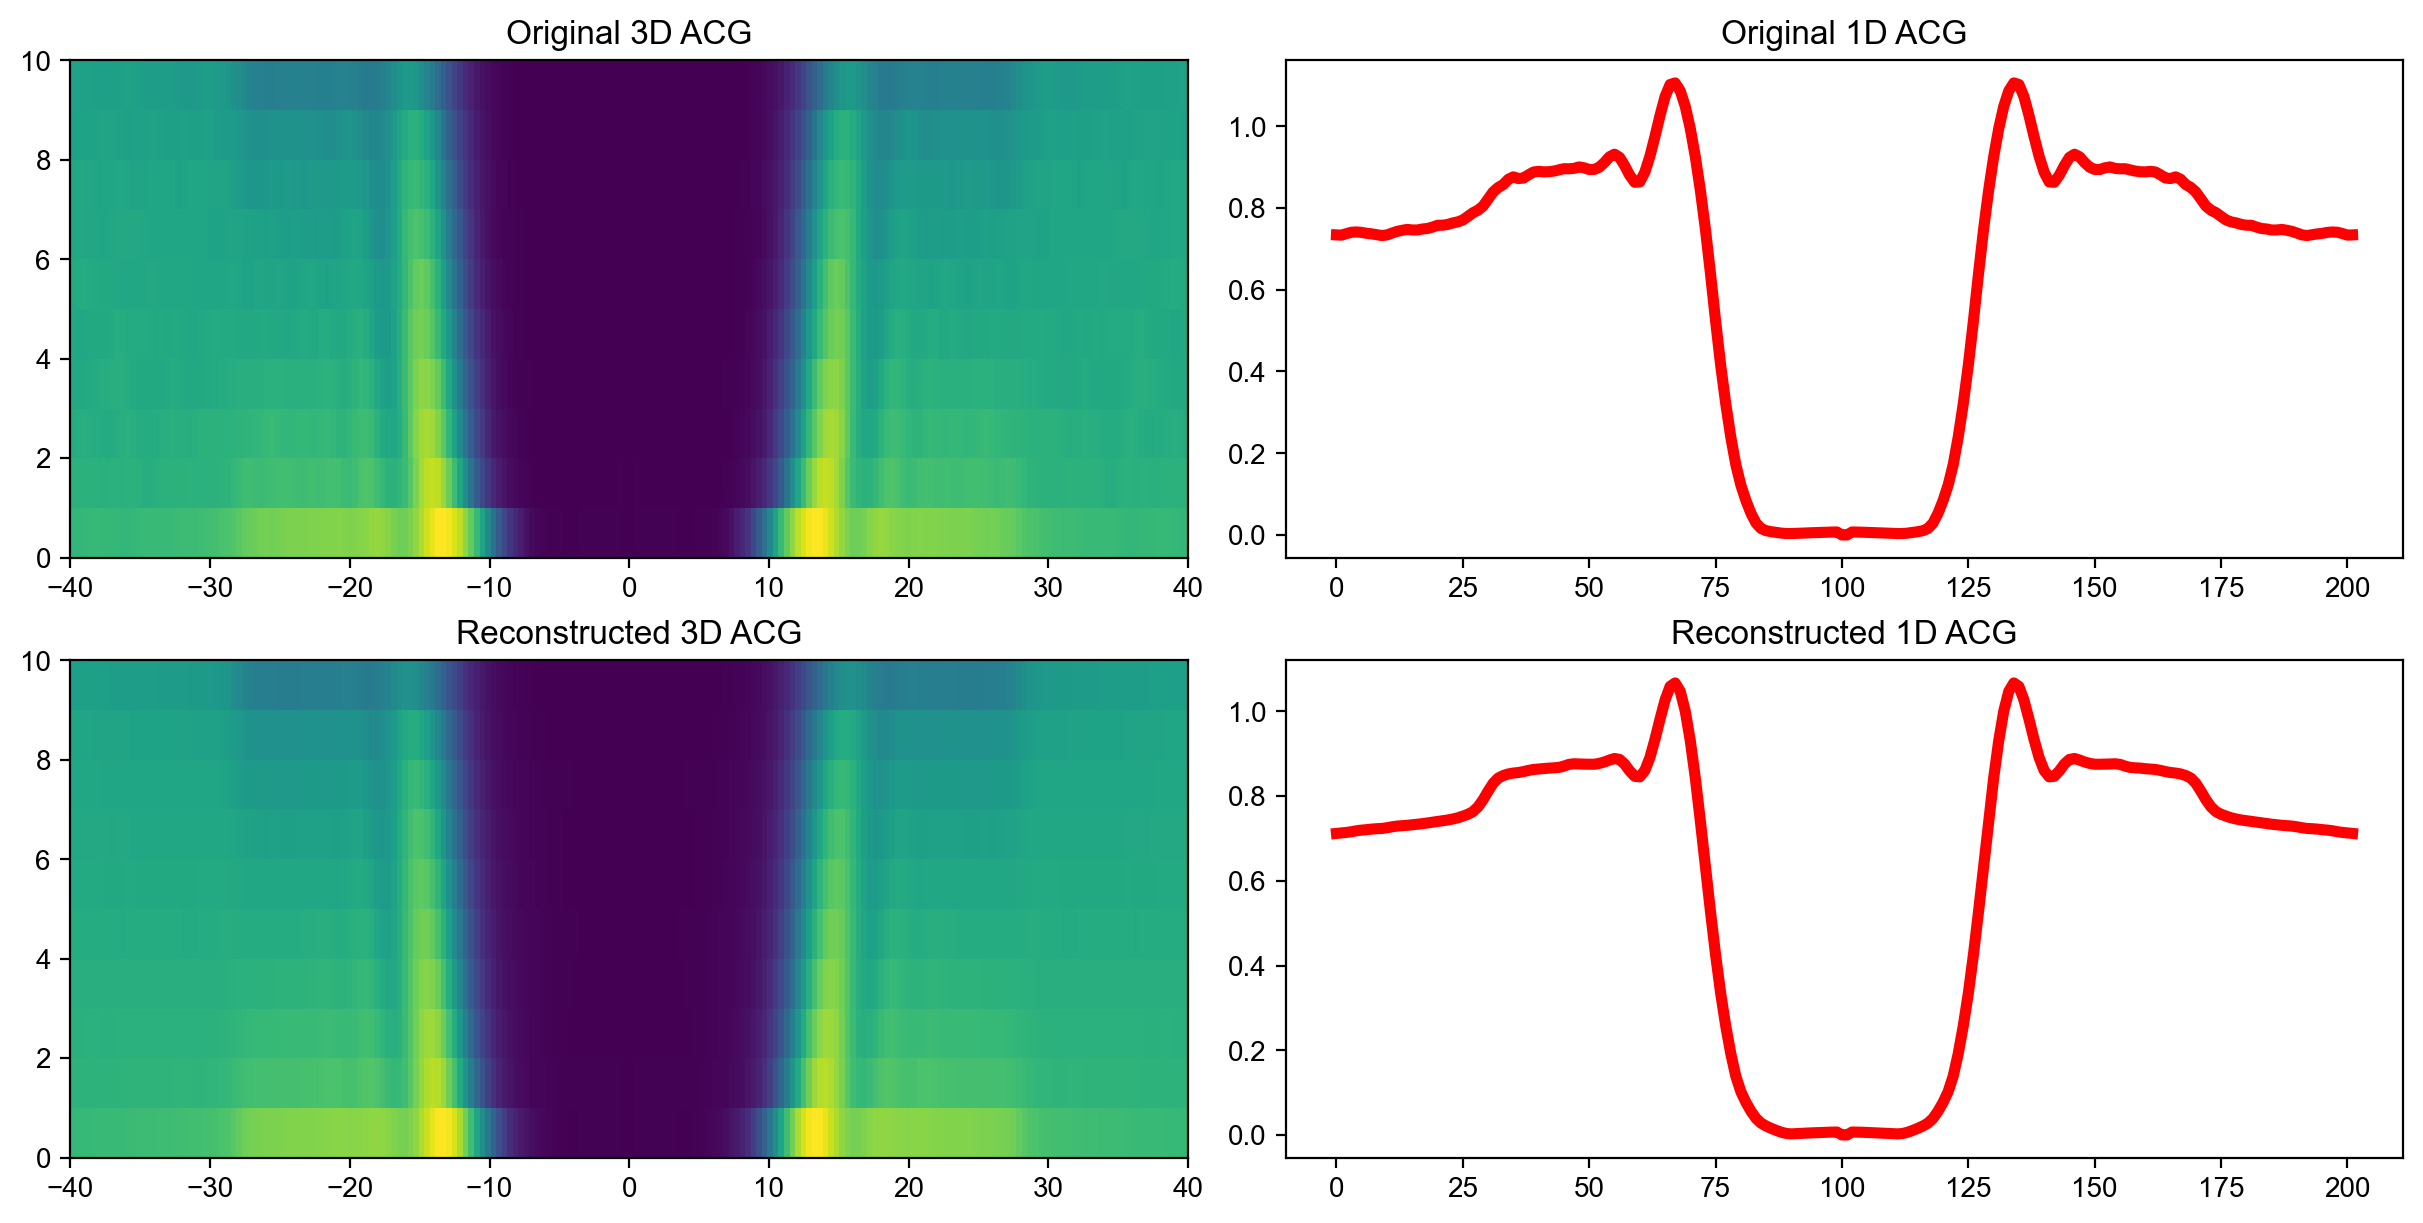

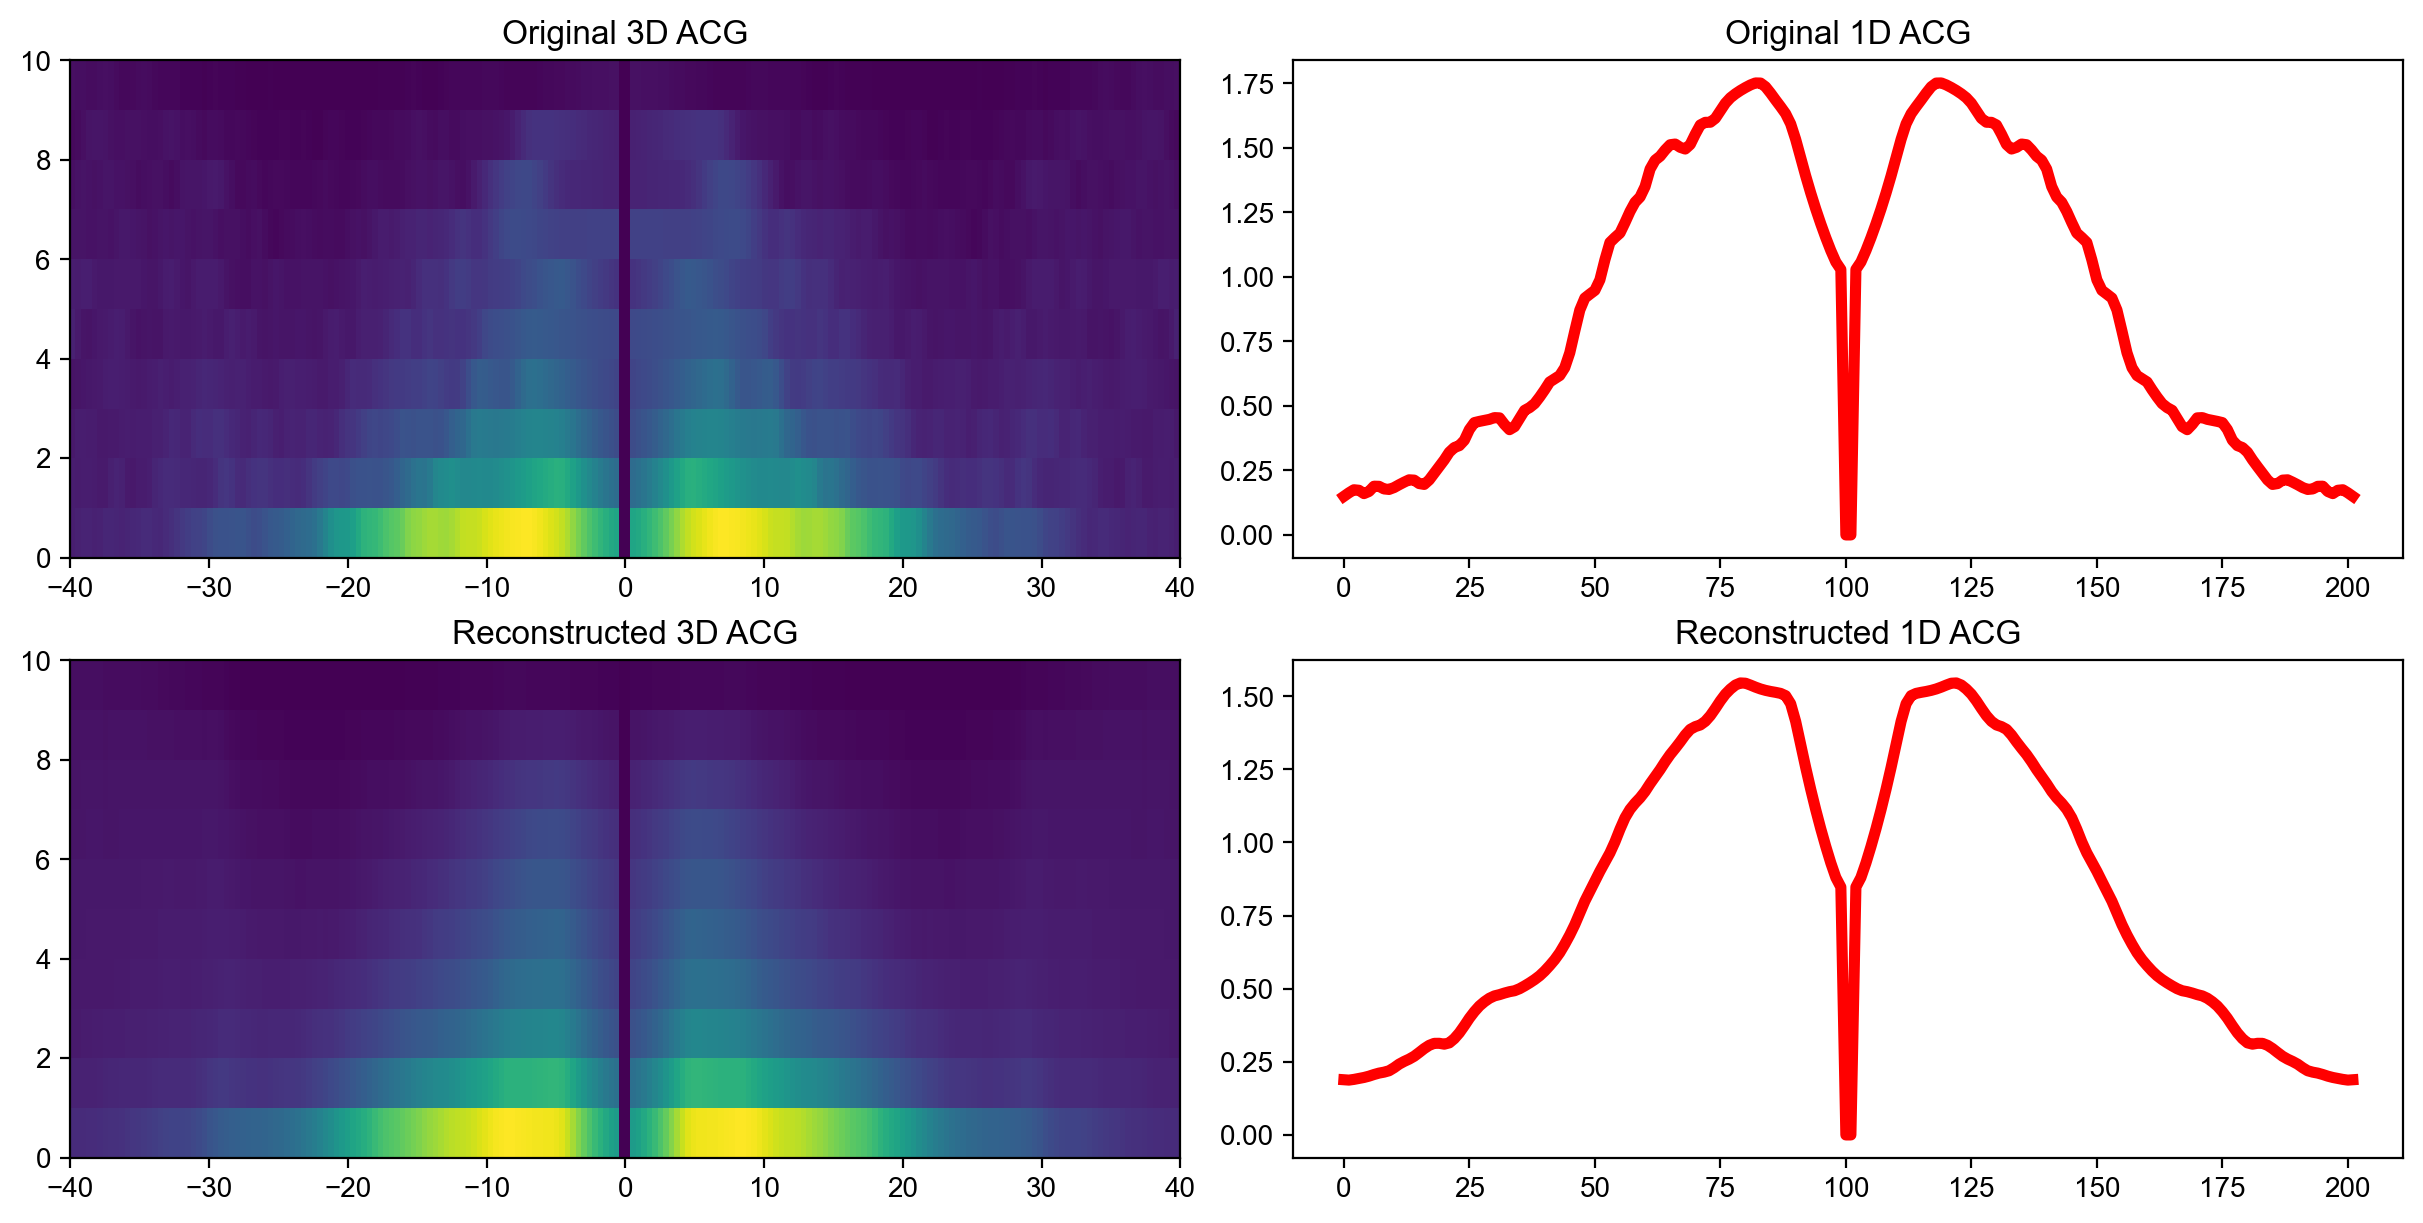

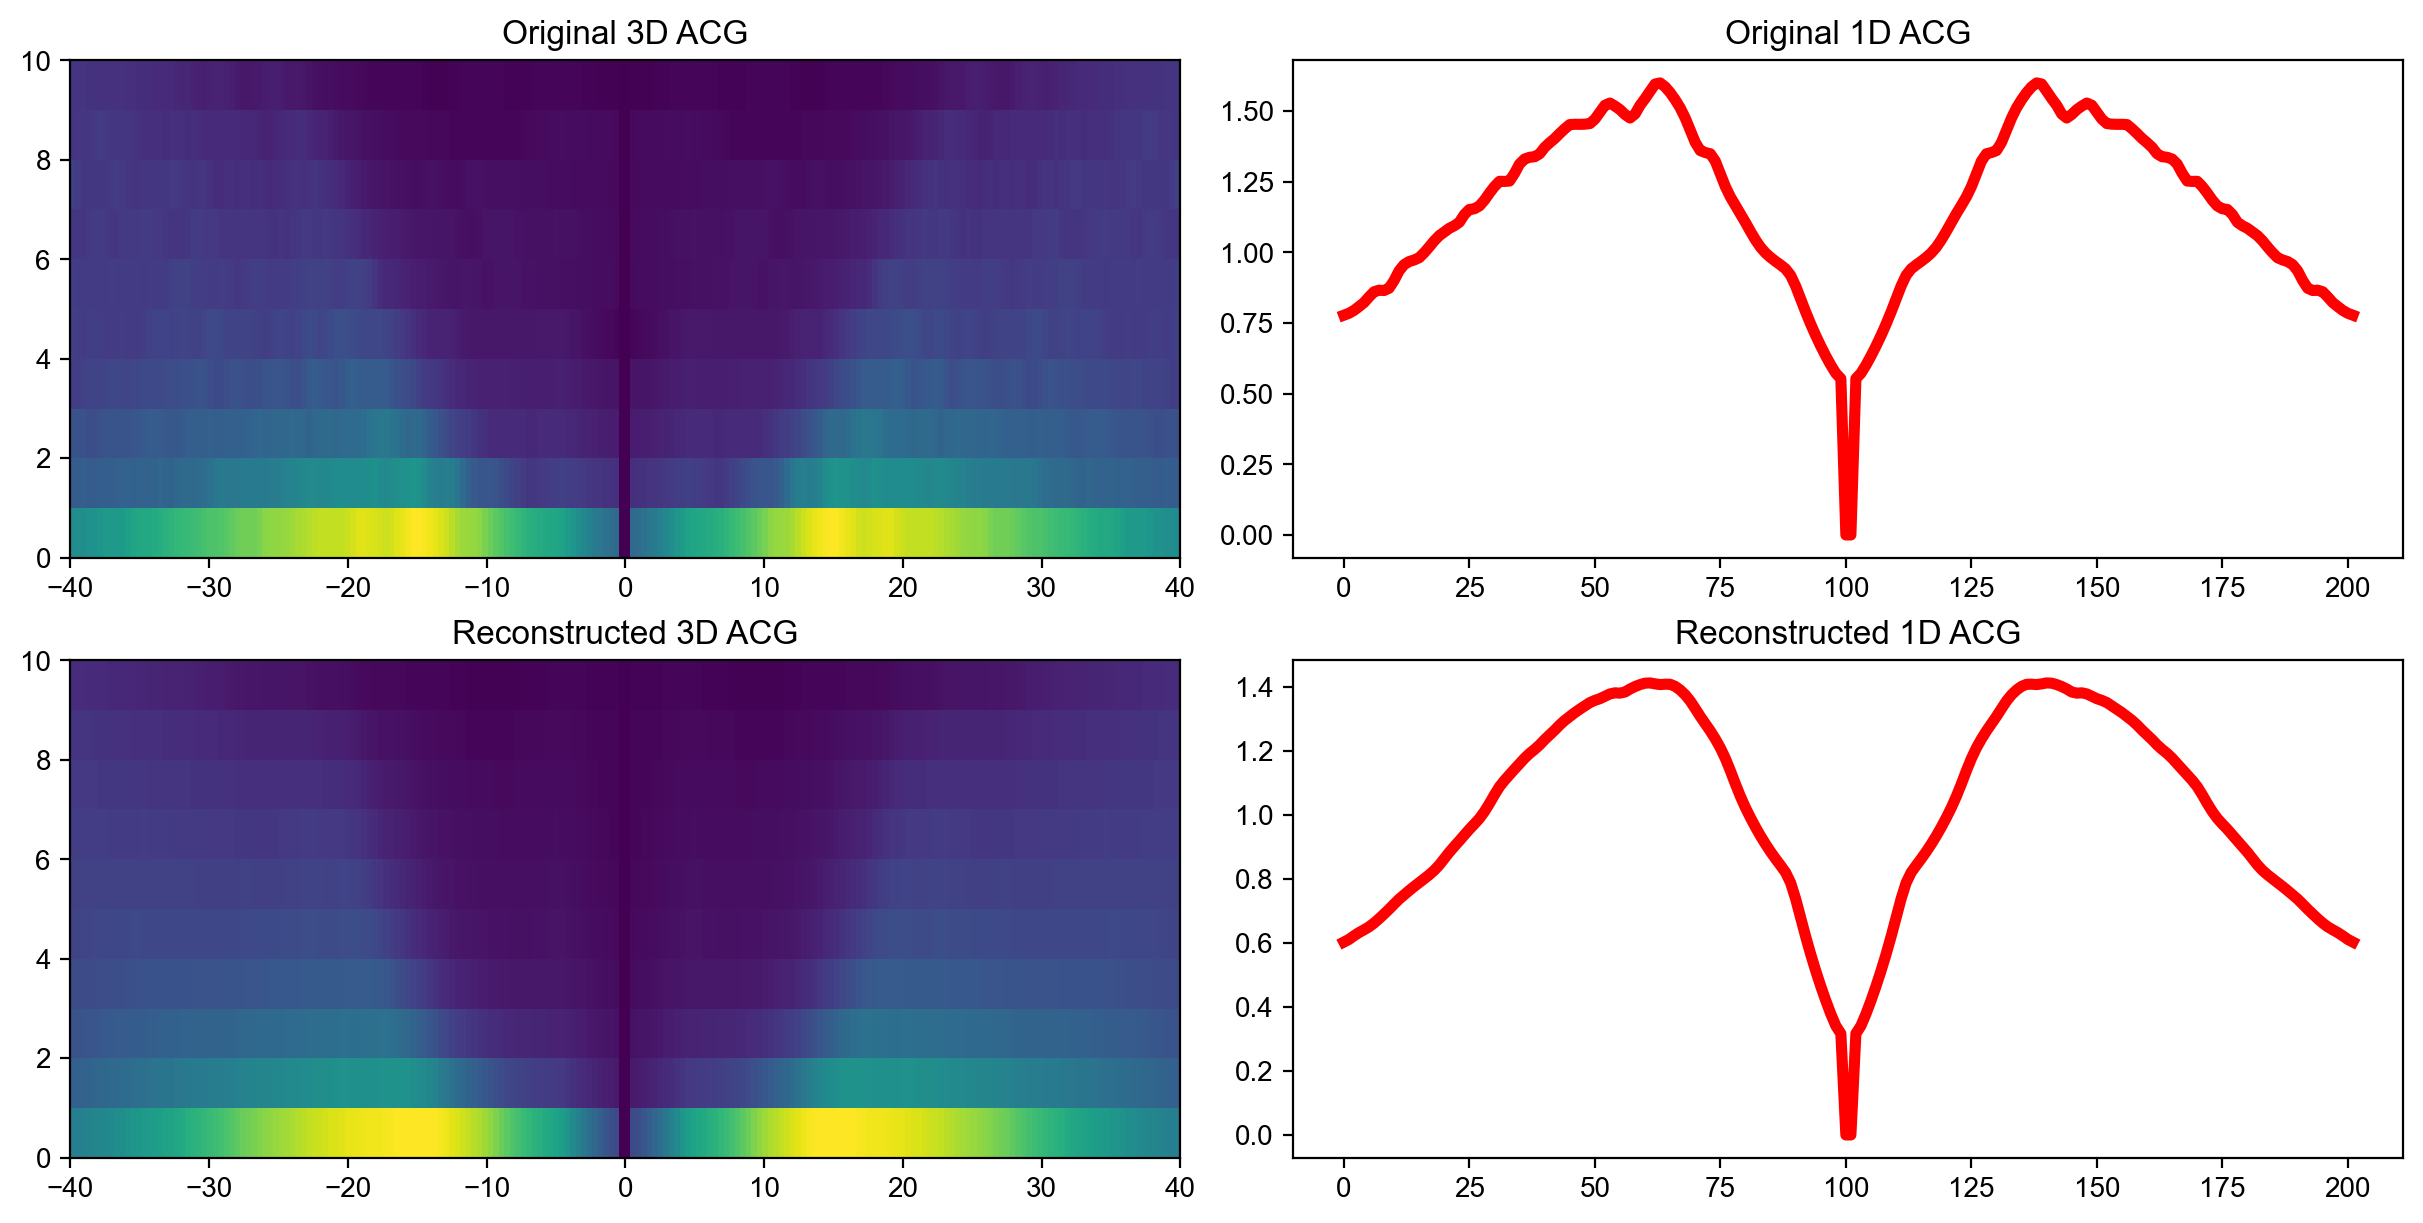

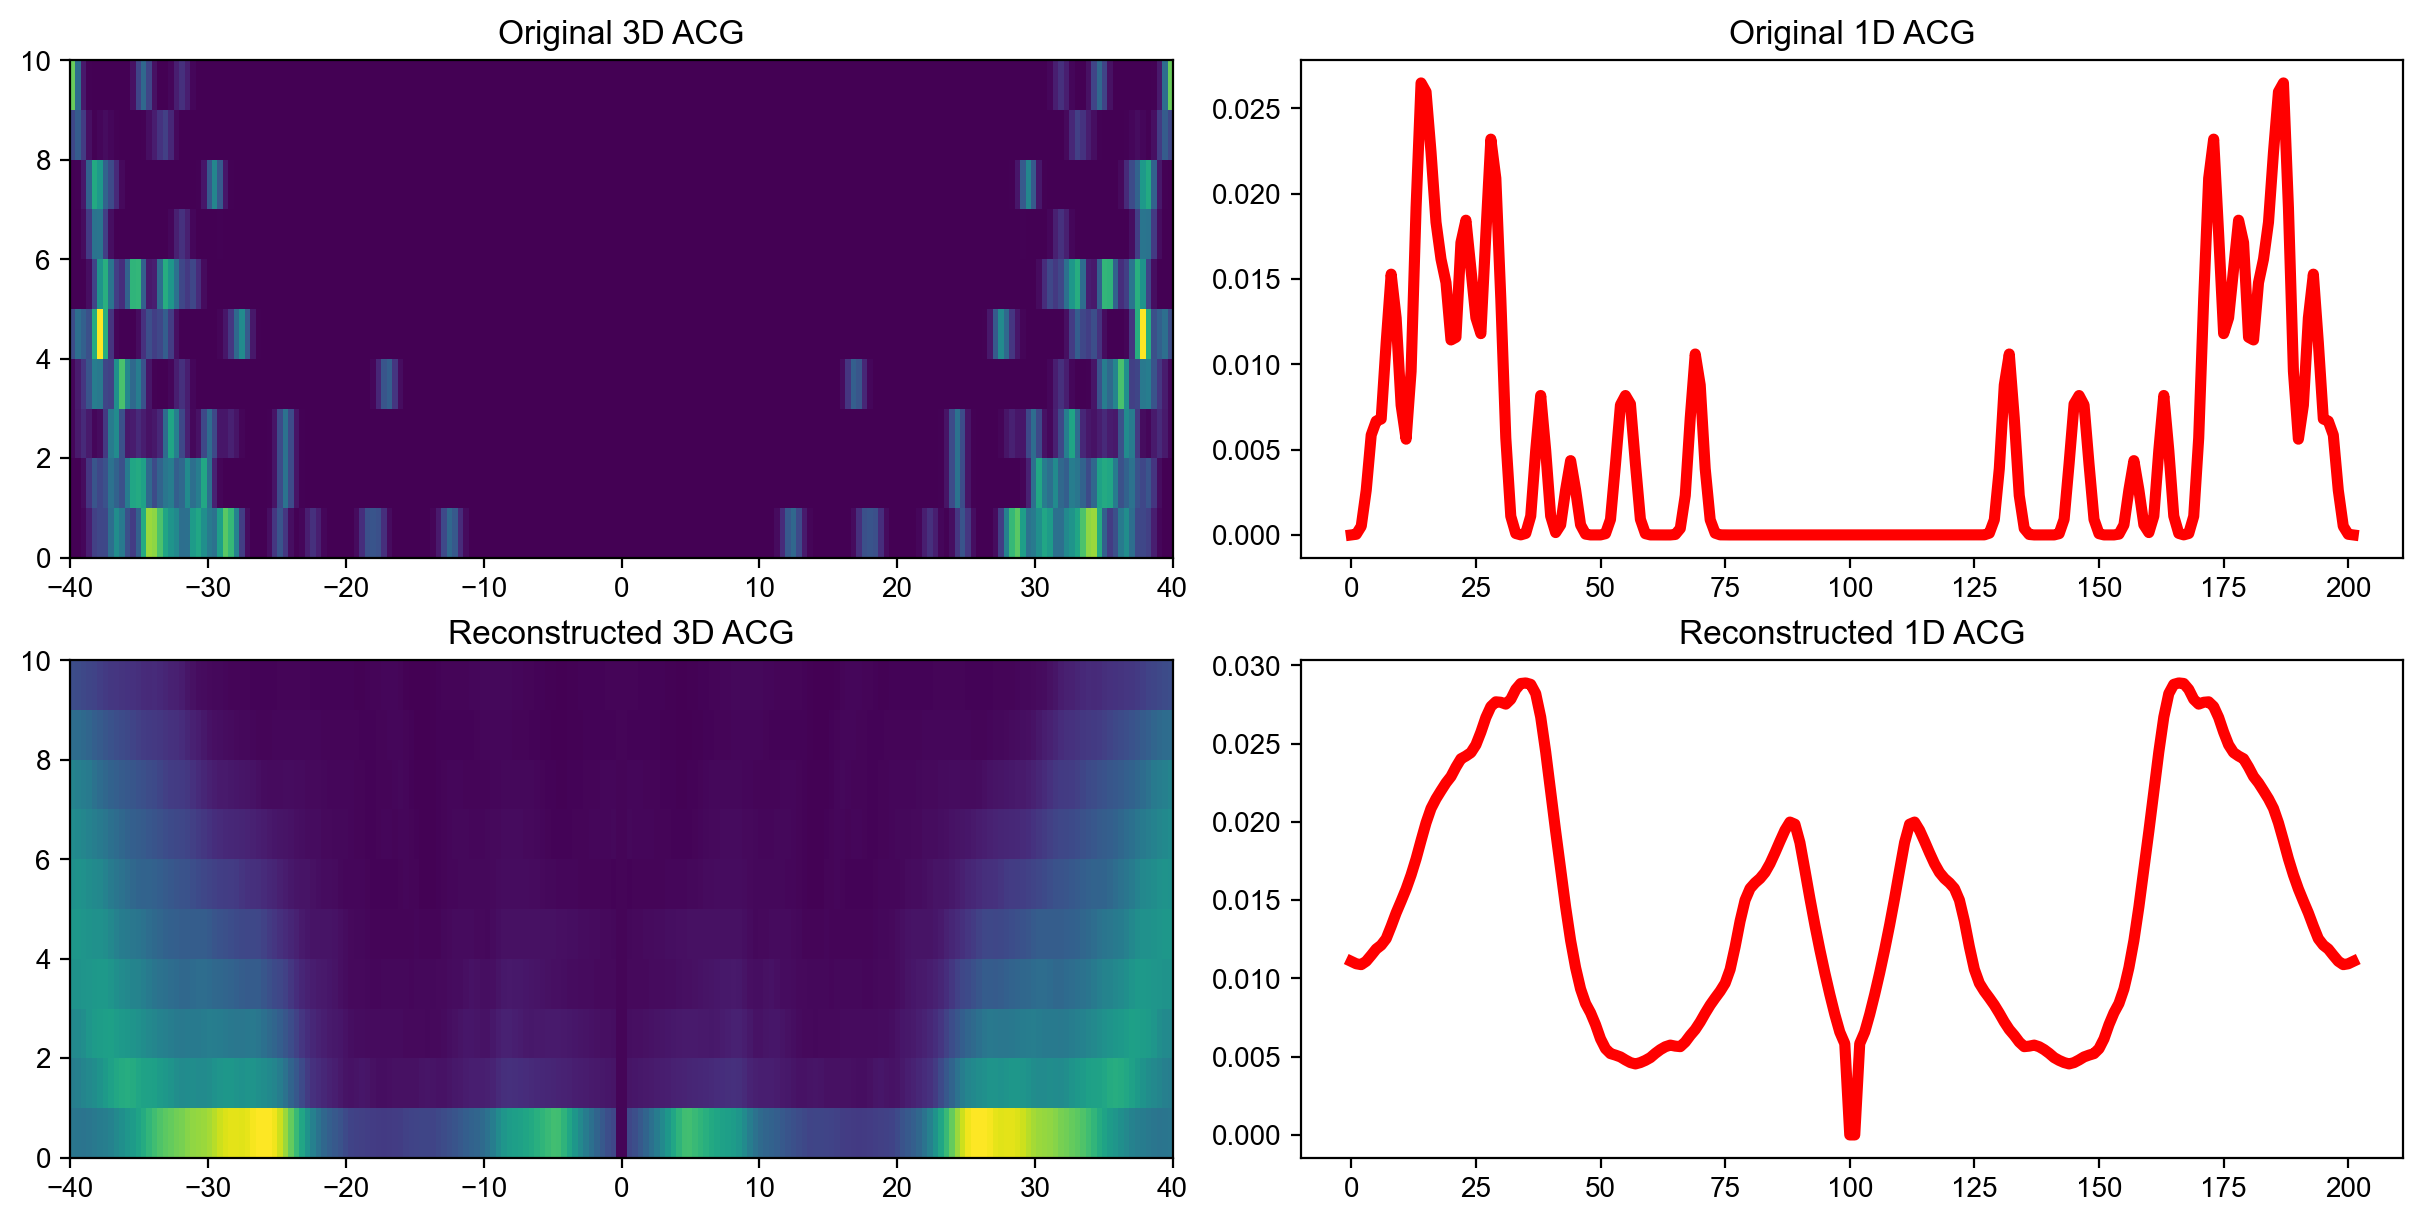

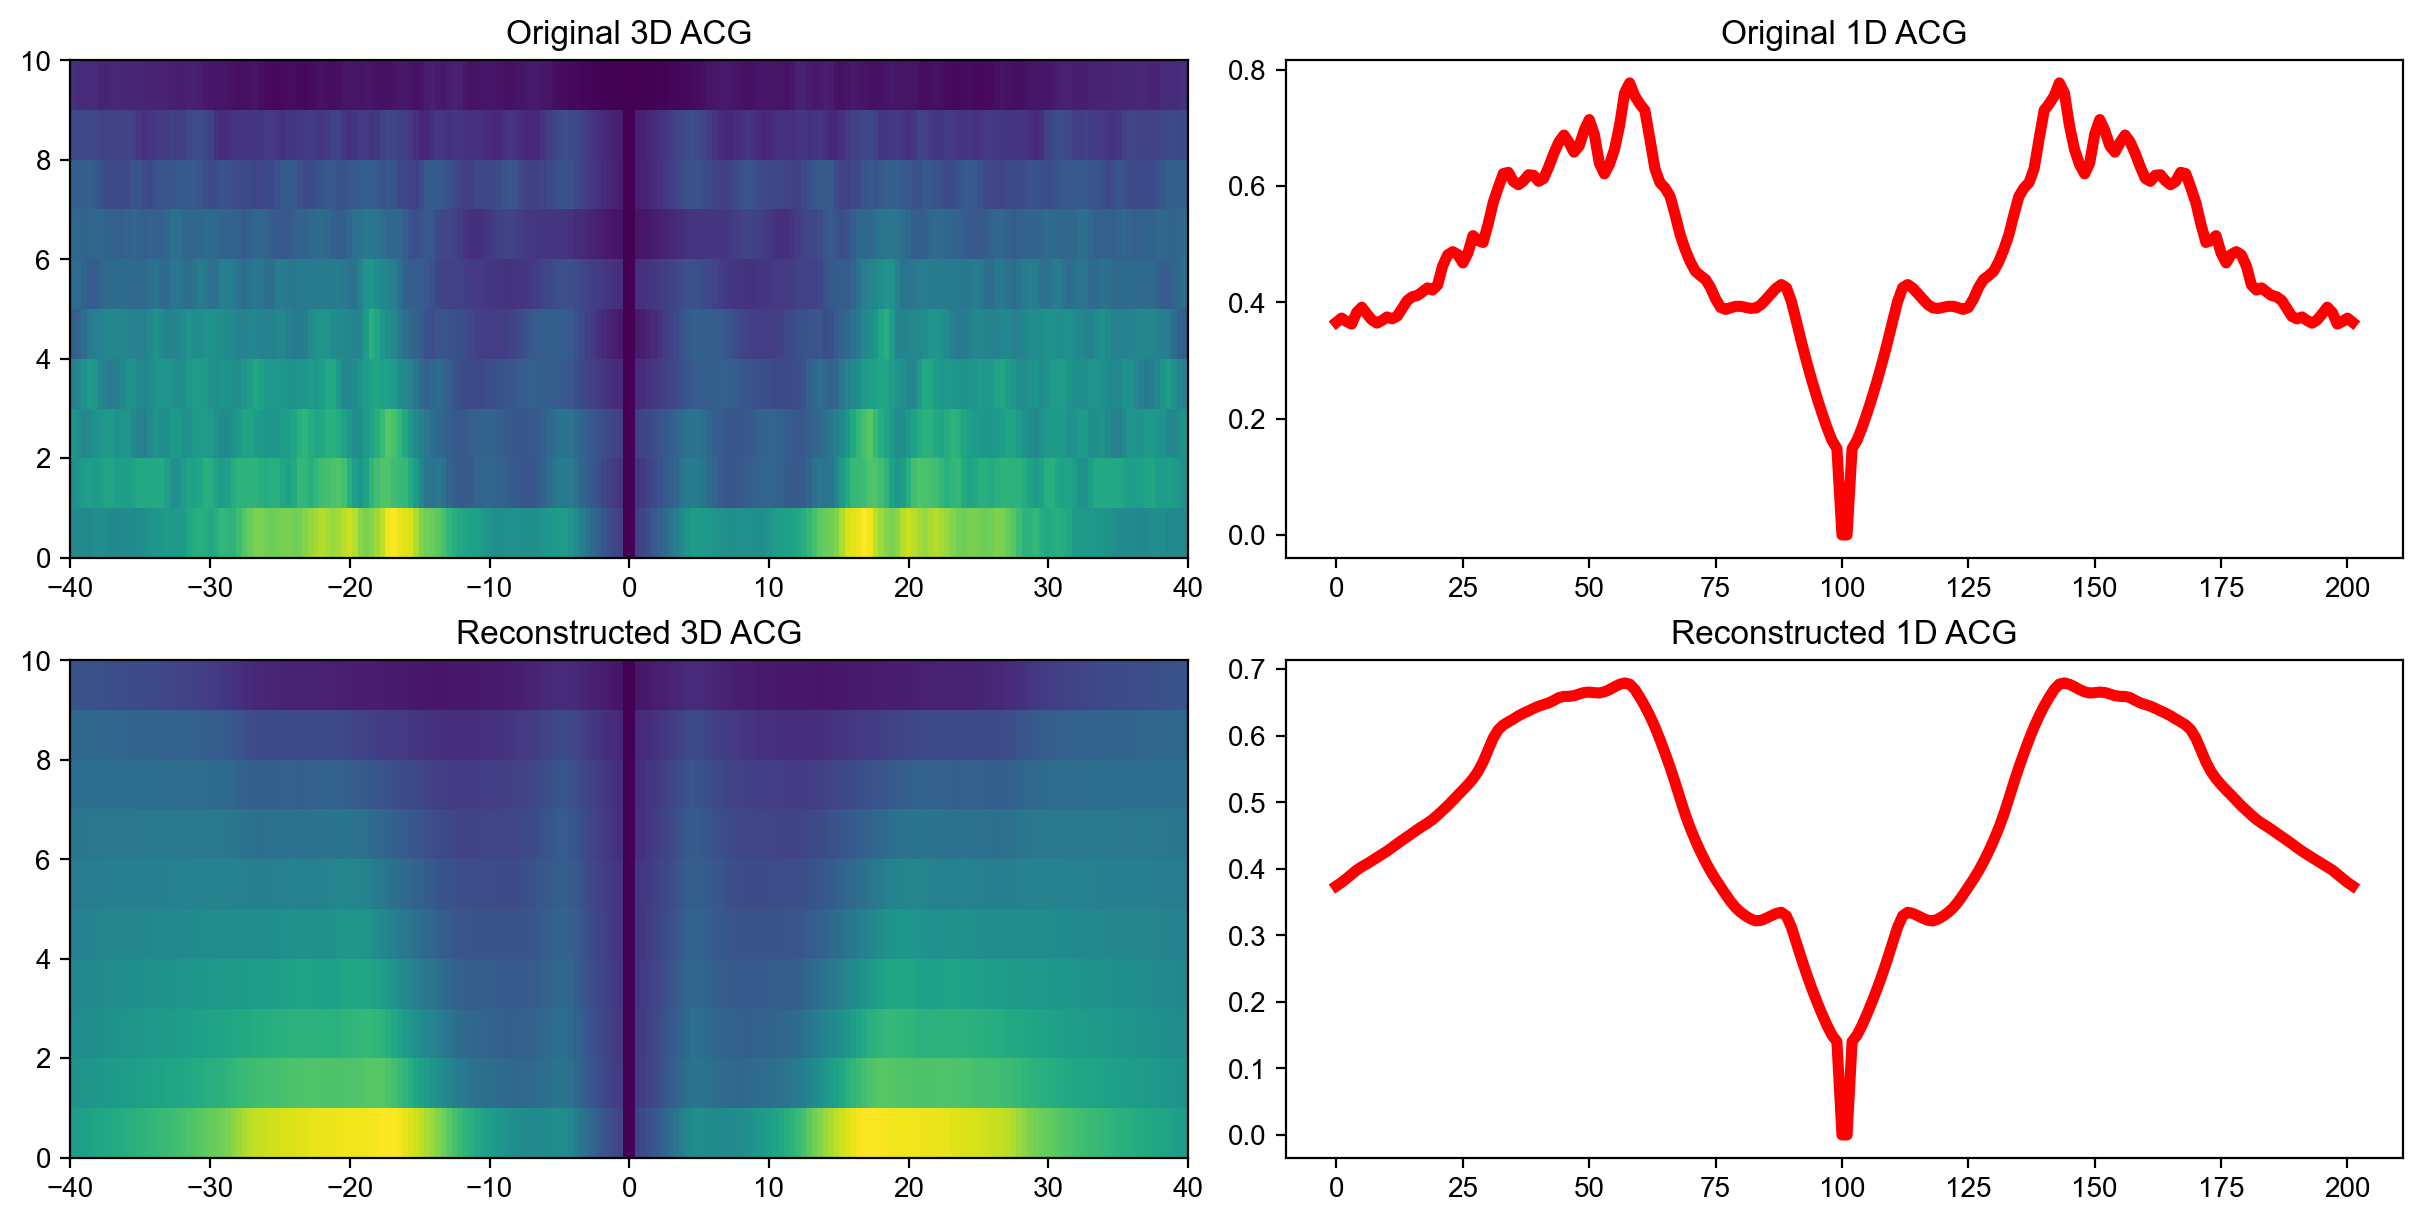

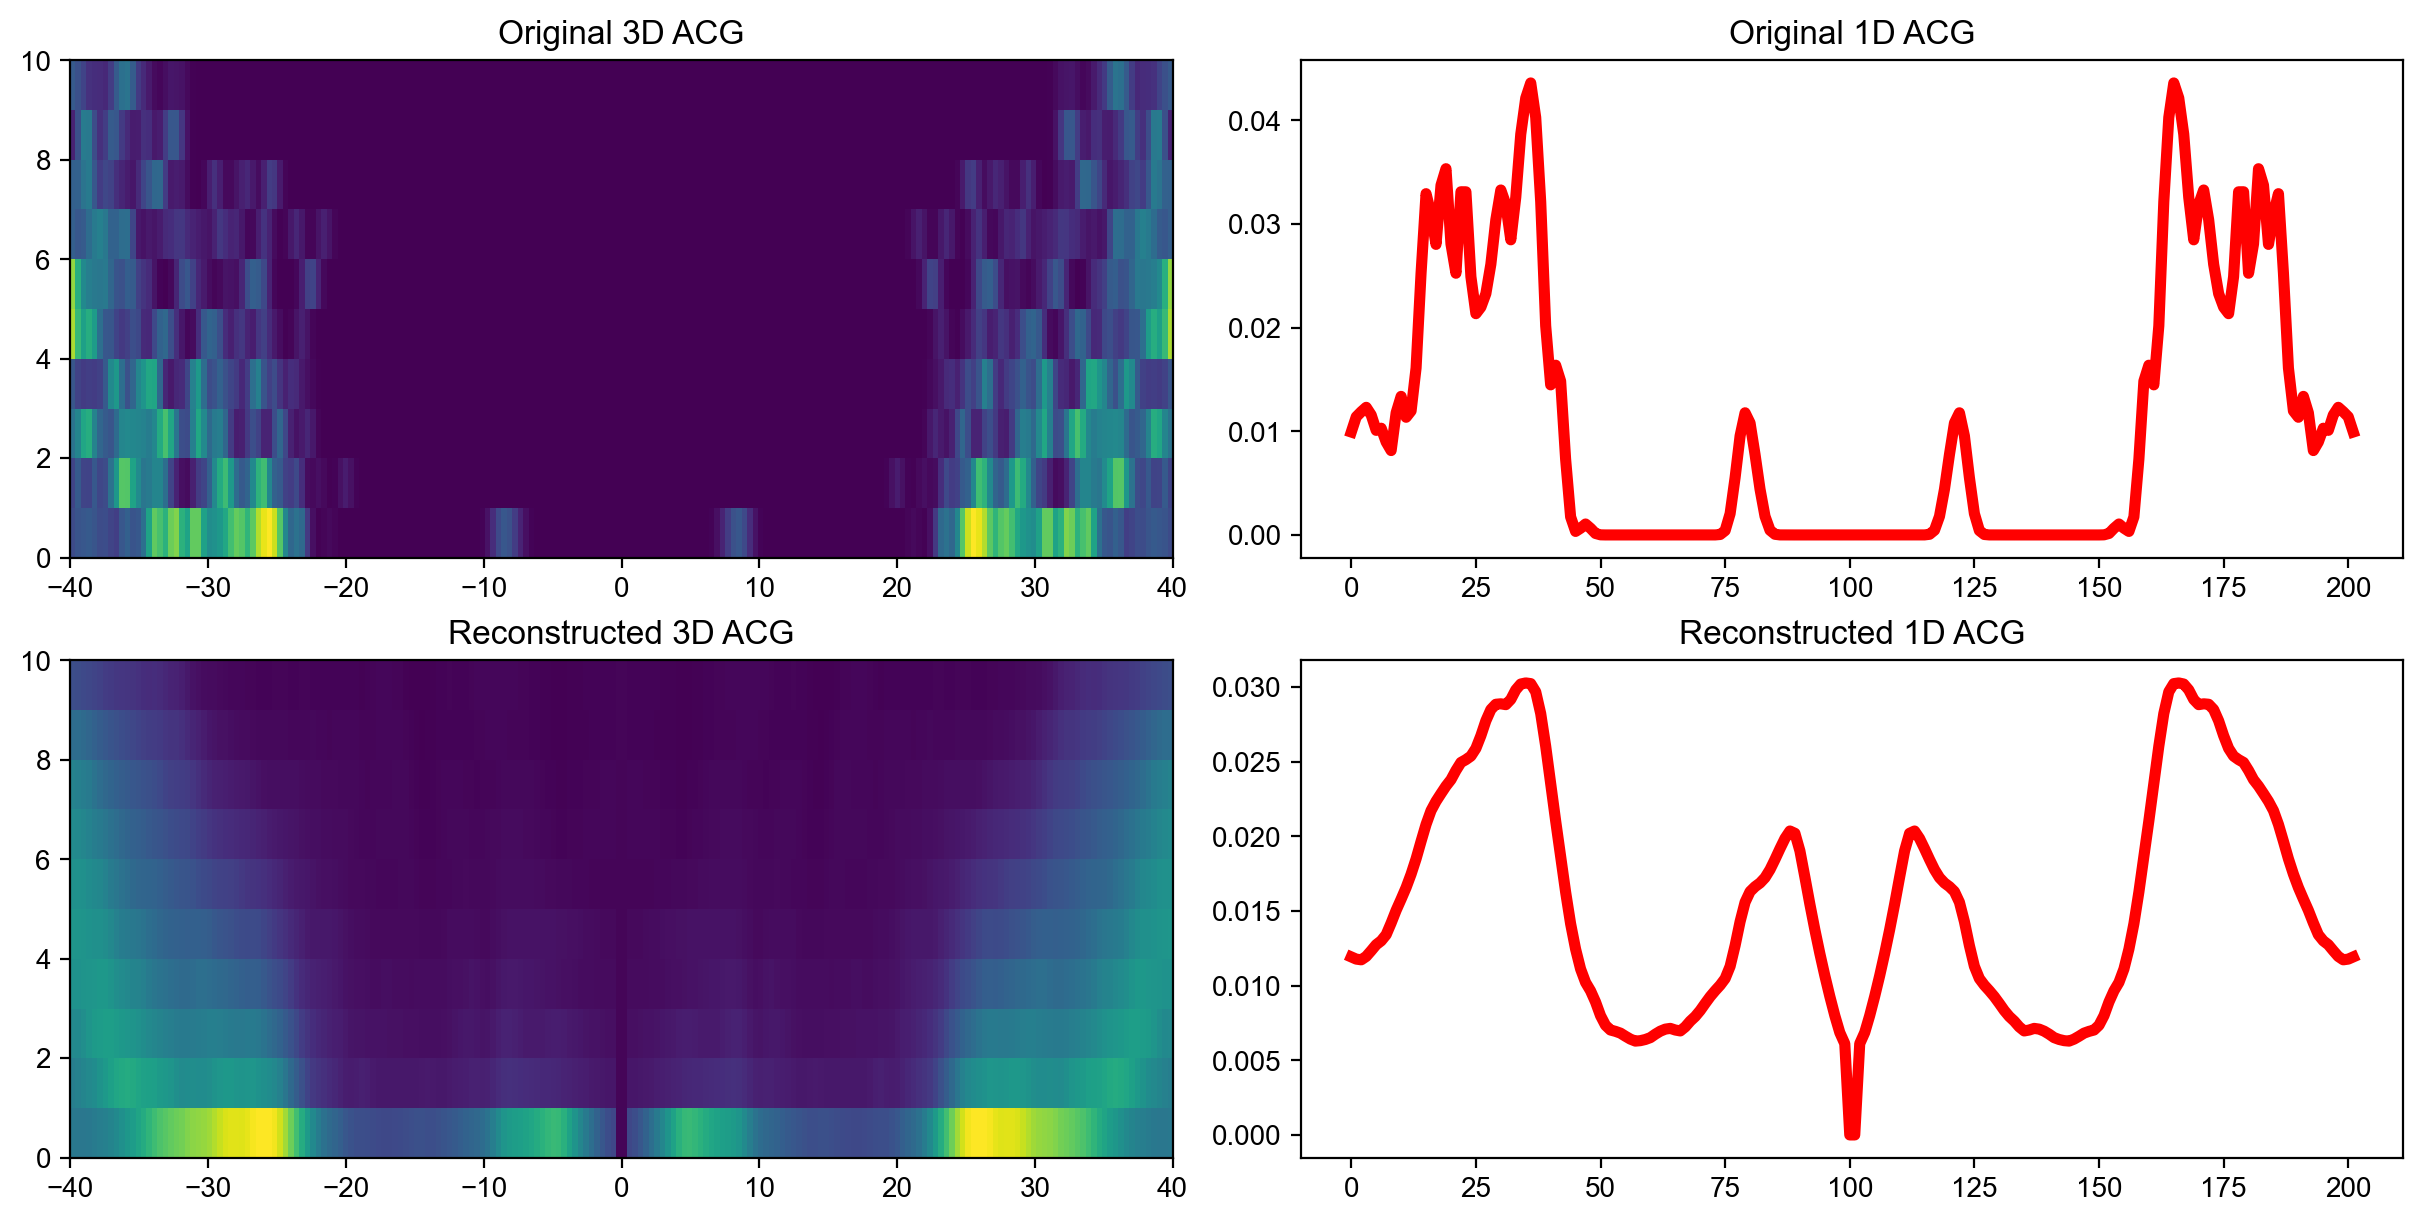

In [33]:
plot_random_reconstruction(input_data, enc.cpu(), dec.cpu(), n_neurons=10)

In [77]:
def plot_2d_latent(
    encoder,
    decoder,
    random_batch,
    n=15,
    save=False,
    std=1,
    channel=None,
    cut=-1,
    mean=False,
):
    """If this is a 2d latent space, it plots the latent space
    If the latent space is larger than 2d, then it plots a 2d cross-section"""
    # Take the first 2 right singular vectors from the SVD of the mean latent space vector over a random batch
    W = torch.linalg.svd(encoder.forward(random_batch).mean).Vh[:2]
    # Take the inverse cdf of n evenly spaced points from 0 to 1
    points = dist.Normal(0, std).icdf(torch.linspace(0.01, 0.99, n))
    # Create a nxn meshgrid with the points
    XX, YY = torch.meshgrid(points, points, indexing="ij")
    # Stack the meshgrid, then reshape to 2 x xxyy. Then transpose so final is xxyy x 2
    XXYY = torch.stack((XX, YY)).reshape(2, -1).T
    # Get the decoder output of W transformed by that matrix. W is 2 x batch_size
    with torch.no_grad():
        out = decoder.forward(XXYY @ W).reshape(-1, 1, 10, 101).numpy().squeeze()

    fig = plt.figure(figsize=(12, 12))
    gs = fig.add_gridspec(ncols=n, nrows=n, hspace=0.1, wspace=0.1)
    axs = gs.subplots()
    count = 0
    if channel is None:
        for i in range(n):
            for j in range(n):
                if mean:
                    axs[i, j].plot(reflected(out[count, :, :cut]).mean(axis=0), c="red")
                else:
                    axs[i, j].imshow(
                        reflected(out[count, :, :cut]),
                        aspect="auto",
                        extent=[-40, 40, 0, 10],
                    )
                axs[i, j].set_yticks([])
                axs[i, j].set_xticks([])
                axs[i, j].label_outer()
                count += 1
    else:
        for i in range(n):
            for j in range(n):
                axs[i, j].plot(reflected(out[count, channel, :cut]))
                axs[i, j].set_yticks([])
                axs[i, j].set_xticks([])
                axs[i, j].label_outer()
                count += 1

    if save:
        plt.savefig(f"wvf_latent_space{n}.pdf")
    plt.show()

In [84]:
plot_2d_latent(
    enc,
    dec,
    torch.tensor(input_data).float().unsqueeze(1),
    n=10,
    std=1,
    save=False,
    channel=None,
    cut=-1,
    mean=True,
)

In [36]:
raise Exception("Stop here")

Exception: Stop here

In [ ]:
# torch.save(
#     enc.state_dict(),
#     os.path.join(
#         Path.home(), ".npyx_c4_resources", "vaes", "3DACG_logscale_encoder.pt"
#     ),
# )
# torch.save(
#     dec.state_dict(),
#     os.path.join(
#         Path.home(), ".npyx_c4_resources", "vaes", "3DACG_logscale_decoder.pt"
#     ),
# )

# Variance explained

In [42]:
input_tensor =  torch.tensor(input_data).float().unsqueeze(1)
reconstructions = dec(enc(input_tensor).mean).reshape(-1, 1, 10, 101).detach()

variance_explained = 1 - F.mse_loss(reconstructions, input_tensor) / torch.var(input_tensor, unbiased=False)
variance_explained.item()

0.9889635443687439